In [1]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00


In [2]:
pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=cddc661ac612340be360b934ea4644ae71b1bf8dbf4abc50e622af51da498a5e
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import ta
import shap
shap.initjs()
warnings.filterwarnings('ignore')

from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [5]:
import yfinance as yf
from tqdm import tqdm

tickers = [
    "AADI.JK","ADMR.JK","ADRO.JK","AKRA.JK","AMMN.JK",
    "AMRT.JK","ANTM.JK","ASII.JK","BBCA.JK","BBNI.JK",
    "BBRI.JK","BBTN.JK","BMRI.JK","BRPT.JK","BUMI.JK",
    "CPIN.JK","CUAN.JK","DEWA.JK","EMTK.JK","ESSA.JK",
    "EXCL.JK","GOTO.JK","HRTA.JK","ICBP.JK","INCO.JK",
    "INDF.JK","INKP.JK","ISAT.JK","ITMG.JK","JPFA.JK",
    "KLBF.JK","MAPI.JK","MBMA.JK","MDKA.JK","MEDC.JK",
    "PGAS.JK","PGEO.JK","PTBA.JK","SCMA.JK","SMGR.JK",
    "TLKM.JK","TOWR.JK","UNTR.JK","UNVR.JK","WIFI.JK"
]
start_date = "2024-12-01"
end_date = "2026-06-30"
all_data = []
for ticker in tqdm(tickers):
    try:

        df = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            auto_adjust=False,
            progress=False
        )

        if df.empty:
            print(f"{ticker} tidak memiliki data.")
            continue

        df.reset_index(inplace=True)

        # Jika kolom berbentuk MultiIndex
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Tambahkan kode saham
        df["Ticker"] = ticker.replace(".JK", "")

        all_data.append(df)

    except Exception as e:
        print(f"Gagal download {ticker}: {e}")
stock_data = pd.concat(all_data, ignore_index=True)
stock_data = stock_data.sort_values(
    by=["Ticker", "Date"]
).reset_index(drop=True)
stock_data = stock_data[
    [
        "Date",
        "Ticker",
        "Open",
        "High",
        "Low",
        "Close",
        "Adj Close",
        "Volume"
    ]
]
print("Jumlah Baris :", stock_data.shape[0])
print("Jumlah Kolom :", stock_data.shape[1])
print("Jumlah Saham :", stock_data["Ticker"].nunique())
stock_data.to_csv("Sahamlq45.csv", index=False)
stock_data.to_excel("LQ45Stock.xlsx", index=False)
print("\nDataset berhasil disimpan.")
print("LQ45_saham.csv")
print ("LQ44 saham.xlsx")

100%|██████████| 45/45 [00:09<00:00,  4.64it/s]


Jumlah Baris : 16647
Jumlah Kolom : 8
Jumlah Saham : 45

Dataset berhasil disimpan.
LQ45_saham.csv
LQ44 saham.xlsx


In [6]:
df = pd.read_csv("Sahamlq45.csv")
df.head()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2024-12-05,AADI,6650.0,6650.0,6650.0,6650.0,5880.733887,459400
1,2024-12-06,AADI,7975.0,7975.0,7975.0,7975.0,7052.458984,446600
2,2024-12-09,AADI,9550.0,9550.0,9550.0,9550.0,8445.264648,43658100
3,2024-12-10,AADI,10500.0,11375.0,9600.0,10275.0,9086.397461,228636600
4,2024-12-11,AADI,10275.0,10450.0,9575.0,9600.0,8489.480469,100219900


In [ ]:
print("INFORMASI DATASET")
print(df.info())
print("\nJumlah Data :", df.shape)
print("\nJumlah Saham :", df["Ticker"].nunique())
print("\nNama Saham :")
print(sorted(df["Ticker"].unique()))

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16647 entries, 0 to 16646
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       16647 non-null  object 
 1   Ticker     16647 non-null  object 
 2   Open       16647 non-null  float64
 3   High       16647 non-null  float64
 4   Low        16647 non-null  float64
 5   Close      16647 non-null  float64
 6   Adj Close  16647 non-null  float64
 7   Volume     16647 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 1.0+ MB
None

Jumlah Data : (16647, 8)

Jumlah Saham : 45

Nama Saham :
['AADI', 'ADMR', 'ADRO', 'AKRA', 'AMMN', 'AMRT', 'ANTM', 'ASII', 'BBCA', 'BBNI', 'BBRI', 'BBTN', 'BMRI', 'BRPT', 'BUMI', 'CPIN', 'CUAN', 'DEWA', 'EMTK', 'ESSA', 'EXCL', 'GOTO', 'HRTA', 'ICBP', 'INCO', 'INDF', 'INKP', 'ISAT', 'ITMG', 'JPFA', 'KLBF', 'MAPI', 'MBMA', 'MDKA', 'MEDC', 'PGAS', 'PGEO', 'PTBA', 'SCMA', 'SMGR', 'TLKM', 'TOWR', 'UNTR', 'UN

In [ ]:
print("\nMissing Value")
print(df.isnull().sum())
print("\nJumlah Data Duplikat :", df.duplicated().sum())


Missing Value
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Jumlah Data Duplikat : 0


In [ ]:
print("\nStatistik Numerik")
print(df.describe())


Statistik Numerik
               Open          High           Low         Close     Adj Close  \
count  16647.000000  16647.000000  16647.000000  16647.000000  16647.000000   
mean    3795.671082   3855.361717   3727.399111   3788.075089   3580.030630   
std     5168.739246   5224.769116   5100.397230   5163.382850   4851.642822   
min       50.000000     50.000000     50.000000     50.000000     50.000000   
25%     1145.000000   1170.000000   1120.000000   1140.000000   1092.621887   
50%     2170.000000   2220.000000   2110.000000   2160.000000   2050.000000   
75%     4380.000000   4440.000000   4300.000000   4380.000000   4040.586670   
max    32625.000000  32825.000000  32200.000000  32500.000000  31381.632812   

             Volume  
count  1.664700e+04  
mean   2.435712e+08  
std    1.081362e+09  
min    0.000000e+00  
25%    1.354430e+07  
50%    3.535440e+07  
75%    1.044262e+08  
max    2.860058e+10  


In [ ]:
import pandas as pd
stock_data = stock_data.sort_values(["Ticker", "Date"]).reset_index(drop=True)
volatility_results = []

for ticker, group in stock_data.groupby("Ticker"):
    group = group.reset_index(drop=True)
    daily_return = group["Adj Close"].pct_change().dropna()

    volatility_results.append({
        "Ticker": ticker,
        "MeanPrice": group["Adj Close"].mean(),
        "StdDailyReturn(%)": daily_return.std() * 100,
        "CV_Price": group["Adj Close"].std() / group["Adj Close"].mean()
    })

volatility_df = pd.DataFrame(volatility_results).sort_values(
    "StdDailyReturn(%)", ascending=False
).reset_index(drop=True)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

print(volatility_df.to_string(index=False))
print("\n--- Ringkasan ---")
print(f"Volatilitas tertinggi : {volatility_df.iloc[0]['Ticker']} "
      f"({volatility_df.iloc[0]['StdDailyReturn(%)']:.2f}%)")
print(f"Volatilitas terendah  : {volatility_df.iloc[-1]['Ticker']} "
      f"({volatility_df.iloc[-1]['StdDailyReturn(%)']:.2f}%)")
print(f"Rata-rata seluruh ticker : {volatility_df['StdDailyReturn(%)'].mean():.2f}%")

volatility_df.to_csv("volatility_per_ticker.xlxs", index=False)

Ticker  MeanPrice  StdDailyReturn(%)  CV_Price
  WIFI    2289.45               6.02      0.36
  CUAN    1382.30               6.02      0.41
  DEWA     306.74               5.52      0.59
  HRTA    1277.95               5.29      0.68
  BRPT    1972.48               5.28      0.51
  BUMI     172.28               5.16      0.49
  MBMA     518.83               4.87      0.28
  MDKA    2324.32               4.59      0.26
  AMMN    6838.68               4.52      0.22
  SCMA     231.95               4.52      0.34
  EMTK     801.56               4.46      0.39
  INCO    4203.75               4.23      0.31
  ADMR    1267.13               3.89      0.31
  ANTM    2668.08               3.65      0.31
  ESSA     617.03               3.50      0.13
  UNVR    1678.31               3.37      0.23
  INKP    7374.47               3.35      0.22
  AADI    7264.92               3.33      0.18
  ISAT    1950.99               3.32      0.13
  SMGR    2525.29               3.29      0.15
  PGEO    107

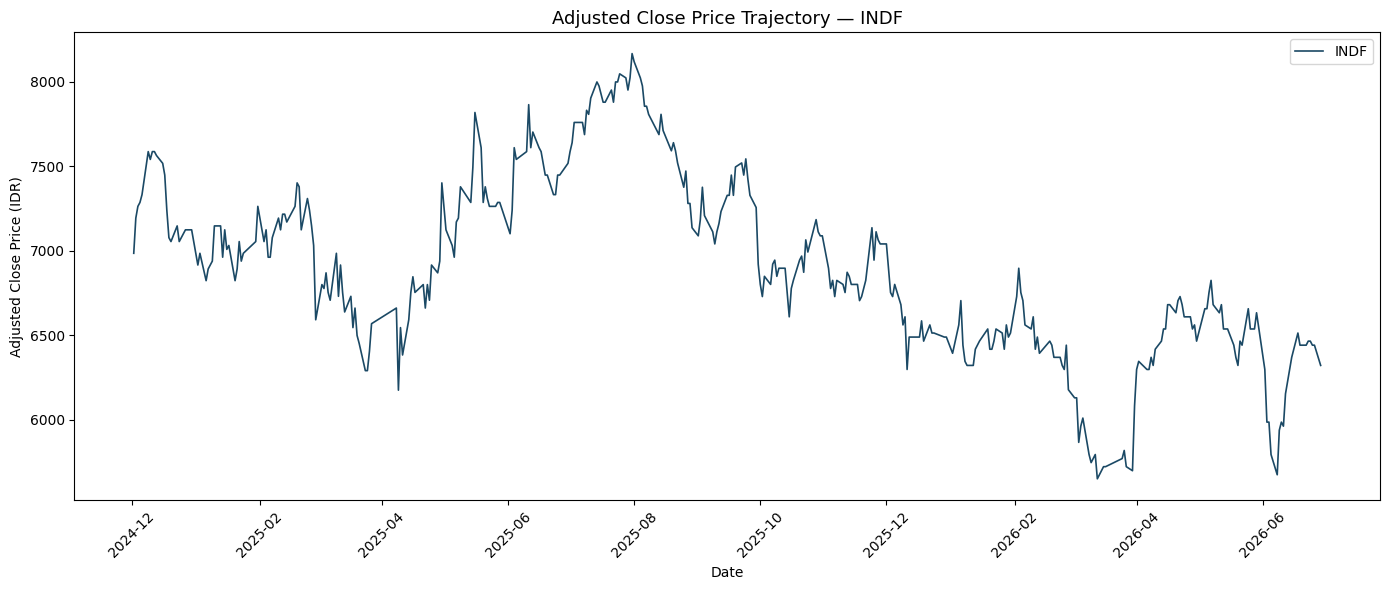

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pastikan Date sudah datetime
df["Date"] = pd.to_datetime(df["Date"])

sample_tickers = ["INDF"]

fig, ax = plt.subplots(figsize=(14, 6))
for ticker in sample_tickers:
    subset = df[df["Ticker"] == ticker].sort_values("Date")
    ax.plot(subset["Date"], subset["Adj Close"], label=ticker, linewidth=1.2, color="#1B4965")

# Interval label tanggal per 2 bulan, biar granularity mirip grid sebelumnya
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

ax.set_title("Adjusted Close Price Trajectory — INDF", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close Price (IDR)")
ax.legend()
plt.tight_layout()
plt.savefig("figure1.png", dpi=300, bbox_inches="tight")
plt.show()

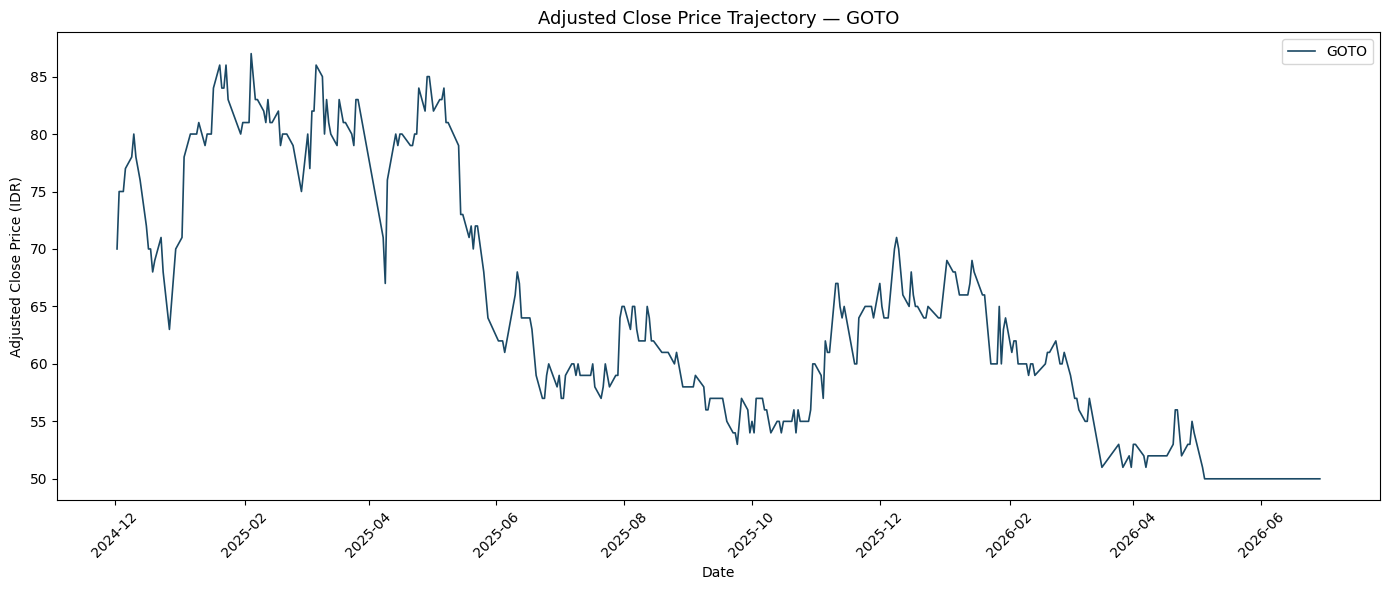

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pastikan Date sudah datetime
df["Date"] = pd.to_datetime(df["Date"])

sample_tickers = ["GOTO"]

fig, ax = plt.subplots(figsize=(14, 6))
for ticker in sample_tickers:
    subset = df[df["Ticker"] == ticker].sort_values("Date")
    ax.plot(subset["Date"], subset["Adj Close"], label=ticker, linewidth=1.2, color="#1B4965")

# Interval label tanggal per 2 bulan, biar granularity mirip grid sebelumnya
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

ax.set_title("Adjusted Close Price Trajectory — GOTO", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close Price (IDR)")
ax.legend()
plt.tight_layout()
plt.savefig("figure1.png", dpi=300, bbox_inches="tight")
plt.show()

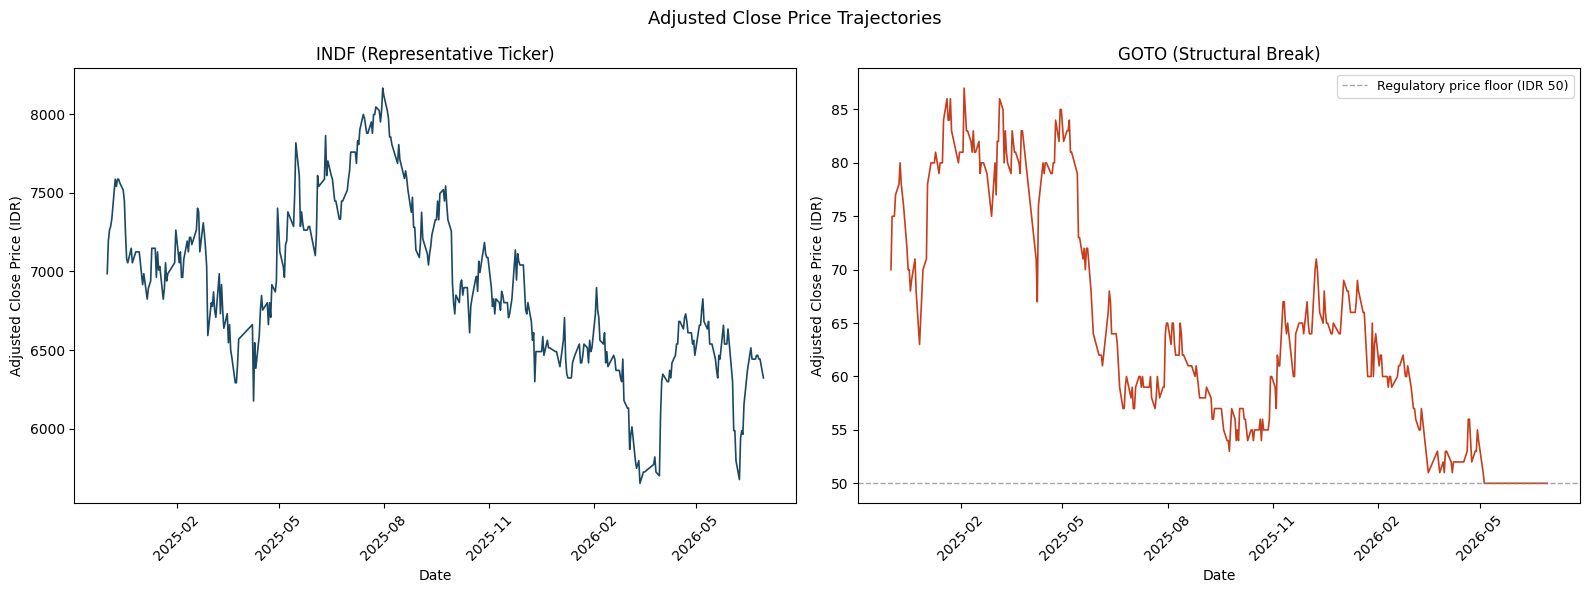

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
df["Date"] = pd.to_datetime(df["Date"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

subset_indf = df[df["Ticker"] == "INDF"].sort_values("Date")
axes[0].plot(subset_indf["Date"], subset_indf["Adj Close"],
             linewidth=1.2, color="#1B4965")
axes[0].set_title("INDF (Representative Ticker)", fontsize=12)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Adjusted Close Price (IDR)")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)


subset_goto = df[df["Ticker"] == "GOTO"].sort_values("Date")
axes[1].plot(subset_goto["Date"], subset_goto["Adj Close"],
             linewidth=1.2, color="#C73E1D")
axes[1].axhline(y=50, color="gray", linestyle="--", linewidth=1, alpha=0.7,
                 label="Regulatory price floor (IDR 50)")
axes[1].set_title("GOTO (Structural Break)", fontsize=12)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Adjusted Close Price (IDR)")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=9)

fig.suptitle("Adjusted Close Price Trajectories",
             fontsize=13)
plt.tight_layout()
plt.savefig("figure1.png", dpi=300, bbox_inches="tight")
plt.show()

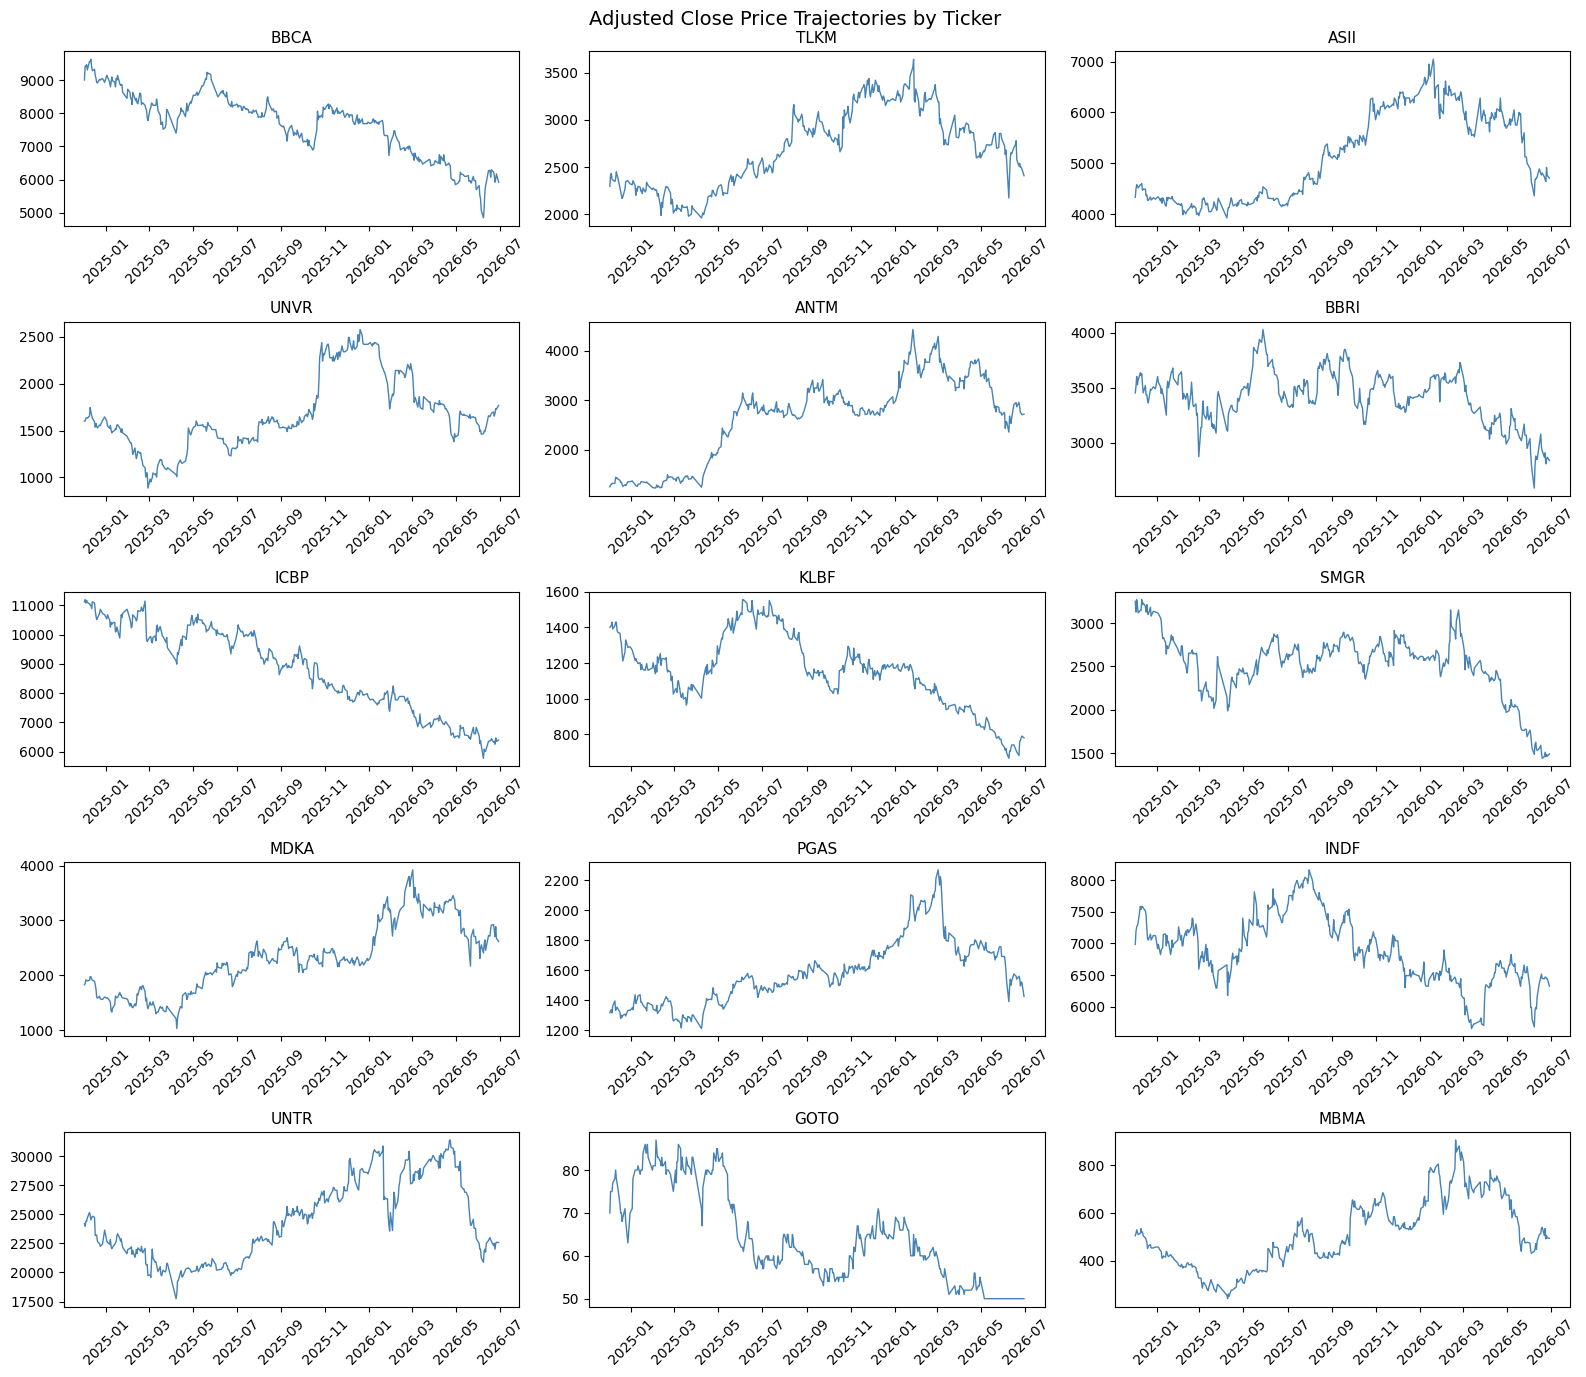

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pastikan Date udah datetime
df["Date"] = pd.to_datetime(df["Date"])

sample_tickers = ["BBCA", "TLKM", "ASII", "UNVR", "ANTM", "BBRI",
                   "ICBP", "KLBF", "SMGR", "MDKA", "PGAS", "INDF","UNTR","GOTO","MBMA"]

fig, axes = plt.subplots(5, 3, figsize=(16, 14))
axes = axes.flatten()

for i, ticker in enumerate(sample_tickers):
    subset = df[df["Ticker"] == ticker].sort_values("Date")
    axes[i].plot(subset["Date"], subset["Adj Close"], color="steelblue", linewidth=1)
    axes[i].set_title(ticker, fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Adjusted Close Price Trajectories by Ticker', fontsize=14)
plt.tight_layout()
plt.show()

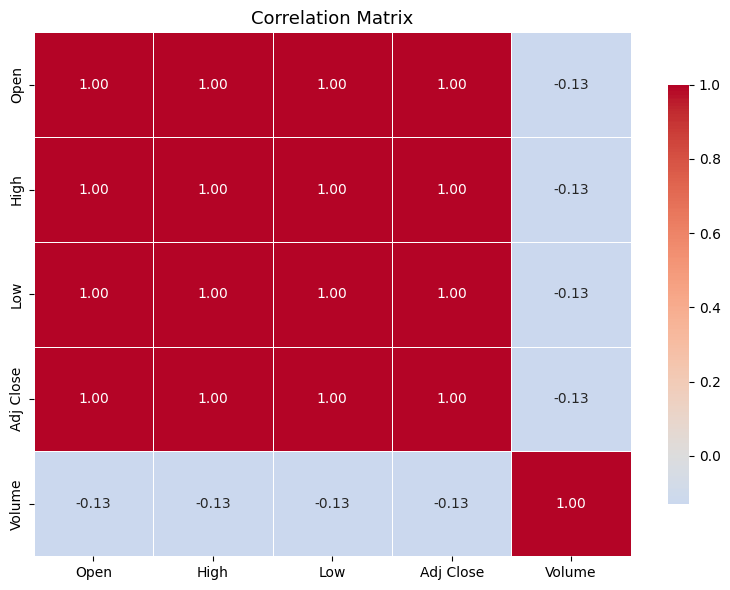

In [ ]:
corr_cols = ['Open', 'High', 'Low', 'Adj Close', 'Volume']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

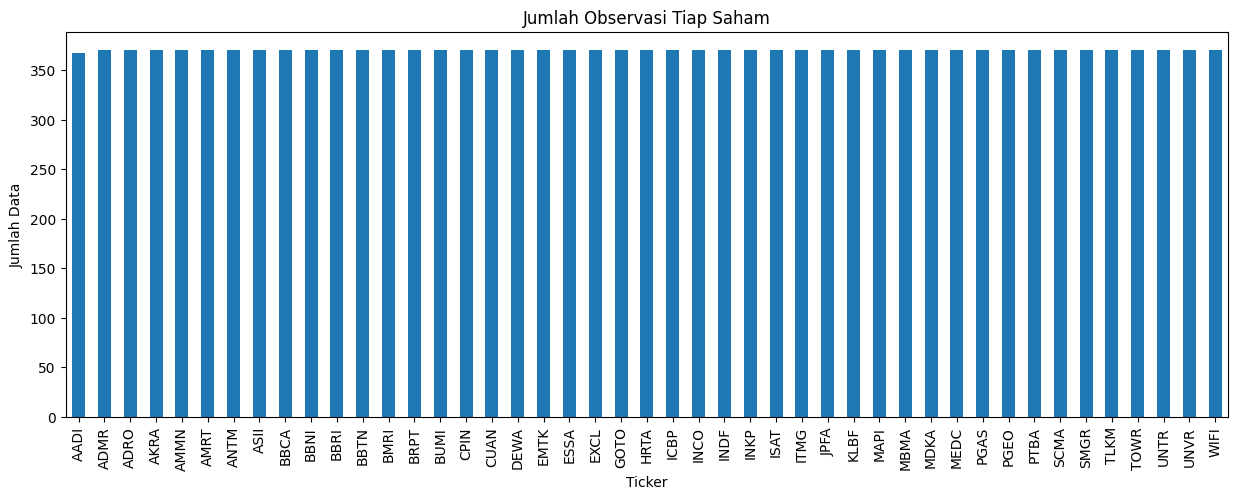

In [ ]:
hitung_saham = df["Ticker"].value_counts().sort_index()
plt.figure(figsize=(15,5))
hitung_saham.plot(kind="bar")
plt.title("Jumlah Observasi Tiap Saham")
plt.ylabel("Jumlah Data")
plt.show()

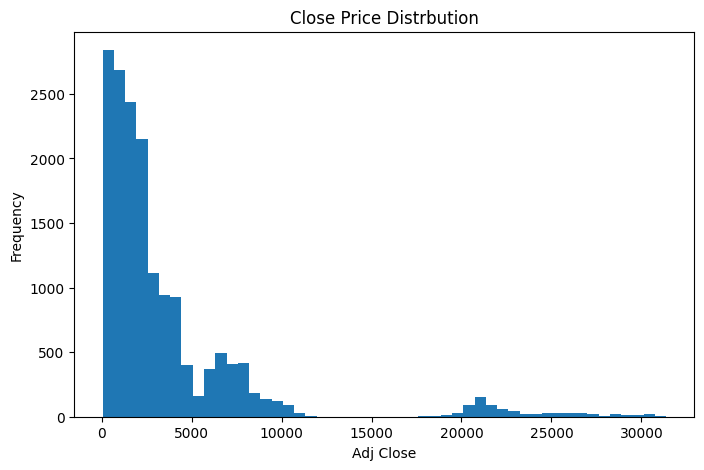

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Adj Close"], bins=50)
plt.title("Close Price Distrbution")
plt.xlabel("Adj Close")
plt.ylabel("Frequency")
plt.show()

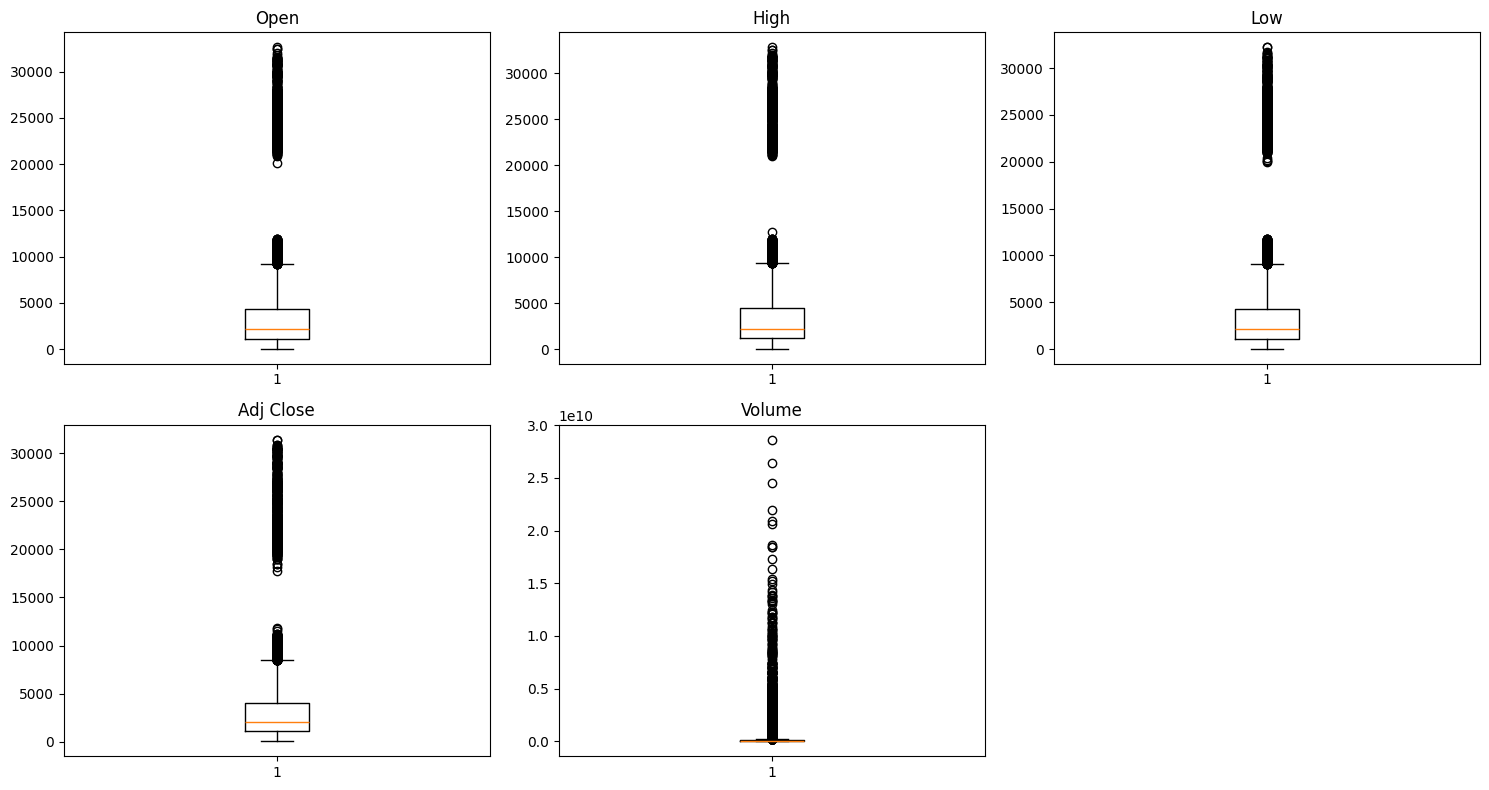

In [ ]:
import matplotlib.pyplot as plt
numerical_cols = ["Open", "High", "Low", "Adj Close", "Volume"]
plt.figure(figsize=(15,8))
for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1)
    plt.boxplot(df[col], vert=True)
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
def count_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers)

numerical_cols = ["Open","High","Low","Close","Adj Close","Volume"]
for col in numerical_cols:
    print(f"{col}: {count_outliers_iqr(df, col)} outlier")

Open: 1113 outlier
High: 1119 outlier
Low: 1116 outlier
Close: 1111 outlier
Adj Close: 1212 outlier
Volume: 1965 outlier


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data = df.copy()

data = data.sort_values(["Ticker", "Date"]).reset_index(drop=True)

data["Ticker"] = le.fit_transform(data["Ticker"])


In [8]:
train_list = []
test_list = []

capping_summary = []

for ticker in data["Ticker"].unique():
    df_ticker = data[data["Ticker"] == ticker].sort_values("Date")
    split_idx = int(len(df_ticker) * 0.8)

    df_train = df_ticker.iloc[:split_idx].copy()
    df_test  = df_ticker.iloc[split_idx:].copy()

    lower = df_train["Volume"].quantile(0.02)
    upper = df_train["Volume"].quantile(0.98)

    # simpan sebelum capping
    train_before = df_train["Volume"].copy()
    test_before  = df_test["Volume"].copy()

    # capping
    df_train["Volume"] = df_train["Volume"].clip(lower, upper)
    df_test["Volume"]  = df_test["Volume"].clip(lower, upper)

    # hitung jumlah data yang berubah
    train_changed = (train_before != df_train["Volume"]).sum()
    test_changed  = (test_before != df_test["Volume"]).sum()

    capping_summary.append({
        "Ticker": le.inverse_transform([ticker])[0],
        "Lower": lower,
        "Upper": upper,
        "Train Changed": train_changed,
        "Test Changed": test_changed
    })

    train_list.append(df_train)
    test_list.append(df_test)

train_data = pd.concat(train_list).reset_index(drop=True)
test_data = pd.concat(test_list).reset_index(drop=True)

summary_df = pd.DataFrame(capping_summary)
summary_df.to_excel("capping_summary.xlsx", index=False)

print(summary_df)



   Ticker        Lower         Upper  Train Changed  Test Changed
0    AADI    4195132.0  6.501436e+07             12             5
1    ADMR    8888310.0  2.346183e+08             12             4
2    ADRO   25843760.0  4.667680e+08             12            11
3    AKRA    6415140.0  7.523088e+07             12             8
4    AMMN    9802120.0  1.048881e+08             12            25
5    AMRT   10262050.0  1.284343e+08             12            12
6    ANTM   23480450.0  5.151229e+08             12             4
7    ASII   15893560.0  1.284791e+08             12            10
8    BBCA   41568240.0  4.541671e+08             12            13
9    BBNI   21433790.0  1.776939e+08             12             8
10   BBRI   87391190.0  5.495645e+08             12             9
11   BBTN    7953260.0  1.133766e+08             12            10
12   BMRI   55524670.0  5.144266e+08             12             4
13   BRPT   30065280.0  5.948163e+08             12            11
14   BUMI 

In [9]:
print("Sebelum")
print(data["Volume"].quantile([0.98, 0.99, 1.00]))

print()

print("Sesudah")
print(train_data["Volume"].quantile([0.98, 0.99, 1.00]))

Sebelum
0.98    2.938823e+09
0.99    4.920679e+09
1.00    2.860058e+10
Name: Volume, dtype: float64

Sesudah
0.98    2.829865e+09
0.99    5.088966e+09
1.00    1.843360e+10
Name: Volume, dtype: float64


In [ ]:
summary_df["Total Changed"] = (
    summary_df["Train Changed"] +
    summary_df["Test Changed"]
)

print(summary_df["Total Changed"].describe())

count    45.000000
mean     22.155556
std       6.728351
min      16.000000
25%      18.000000
50%      20.000000
75%      23.000000
max      44.000000
Name: Total Changed, dtype: float64


In [ ]:
print("Sebelum")
print(data["Volume"].describe())

print()

print("Sesudah")
print(train_data["Volume"].describe())

Sebelum
count    1.664700e+04
mean     2.435712e+08
std      1.081362e+09
min      0.000000e+00
25%      1.354430e+07
50%      3.535440e+07
75%      1.044262e+08
max      2.860058e+10
Name: Volume, dtype: float64

Sesudah
count    1.331700e+04
mean     2.418938e+08
std      1.066739e+09
min      4.505200e+05
25%      1.412060e+07
50%      3.596480e+07
75%      1.026455e+08
max      1.843360e+10
Name: Volume, dtype: float64


In [10]:
import ta

def feature_engineering(data, label=""):

    data = data.sort_values(["Ticker","Date"]).copy()

    # LAG
    lag_columns = ["Open","High","Low","Adj Close","Volume"]

    for col in lag_columns:
        for lag in range(1,6):
            data[f"{col.replace(' ','_')}_lag{lag}"] = (
                data.groupby("Ticker")[col]
                .shift(lag)
            )


    # SMA
    for window in [5,15,20]:

        sma = (
            data.groupby("Ticker")["Adj Close"]
            .transform(lambda x: x.rolling(window).mean())
        )

        data[f"SMA_{window}"] = data["Adj Close"] / sma


    # EMA
    for window in [5,15,20]:

        ema = (
            data.groupby("Ticker")["Adj Close"]
            .transform(lambda x: x.ewm(span=window,adjust=False).mean())
        )

        data[f"EMA_{window}"] = data["Adj Close"] / ema


    # MACD
    def add_macd(group):

        ema12 = group["Adj Close"].ewm(span=12,adjust=False).mean()
        ema26 = group["Adj Close"].ewm(span=26,adjust=False).mean()

        macd = ema12 - ema26
        signal = macd.ewm(span=9,adjust=False).mean()

        # Normalisasi MACD menjadi rasio sesuai Persamaan (2.8):
        # r_MACD,t = (MACD_t - SIG_t) / (0.5 * (|MACD_t| + |SIG_t|))
        denominator = 0.5 * (macd.abs() + signal.abs())

        group["MACD"] = (macd - signal) / denominator

        return group

    data = data.groupby(
        "Ticker",
        group_keys=False
    ).apply(add_macd)



    # RSI
    def add_rsi(group):

        group["RSI"] = ta.momentum.RSIIndicator(
            close=group["Adj Close"],
            window=14
        ).rsi()

        return group

    data = data.groupby(
        "Ticker",
        group_keys=False
    ).apply(add_rsi)


    # STOCHASTIC
    def add_stochastic(group):

        adj_ratio = group["Adj Close"] / group["Close"]

        high_adj = group["High"] * adj_ratio
        low_adj = group["Low"] * adj_ratio

        stoch = ta.momentum.StochasticOscillator(
            high=high_adj,
            low=low_adj,
            close=group["Adj Close"],
            window=14,
            smooth_window=3
        )

        group["STOCH_K"] = stoch.stoch()
        group["STOCH_D"] = stoch.stoch_signal()

        return group

    data = data.groupby(
        "Ticker",
        group_keys=False
    ).apply(add_stochastic)


    # TARGET
    data["Target"] = (
        data.groupby("Ticker")["Adj Close"]
        .shift(-1)
    )

    print(f"Sebelum dropna - {label}:", data.shape)

    data = data.dropna().reset_index(drop=True)

    print(f"Sesudah dropna - {label}:", data.shape)

    return data

In [11]:
train_data = feature_engineering(train_data, label="Train")
test_data  = feature_engineering(test_data, label="Test")

print("Train :", train_data.shape)
print("Test  :", test_data.shape)

Sebelum dropna - Train: (13317, 44)
Sesudah dropna - Train: (12417, 44)
Sebelum dropna - Test: (3330, 44)
Sesudah dropna - Test: (2413, 44)
Train : (12417, 44)
Test  : (2413, 44)


In [12]:
features = [
    "Open",
    "High",
    "Low",
    "Volume",
    "Adj_Close_lag1",
    "Adj_Close_lag2",
    "Adj_Close_lag3",
    "Adj_Close_lag4",
    "Adj_Close_lag5",
    "Open_lag1",
    "Open_lag2",
    "Open_lag3",
    "Open_lag4",
    "Open_lag5",
    "High_lag1",
    "High_lag2",
    "High_lag3",
    "High_lag4",
    "High_lag5",
    "Low_lag1",
    "Low_lag2",
    "Low_lag3",
    "Low_lag4",
    "Low_lag5",
    "Volume_lag1",
    "Volume_lag2",
    "Volume_lag3",
    "Volume_lag4",
    "Volume_lag5",
    "SMA_5",
    "SMA_15",
    "SMA_20",
    "EMA_5",
    "EMA_15",
    "EMA_20",
    "MACD",
    "RSI",
    "STOCH_K",
    "STOCH_D"
]

target = "Target"
if "Ticker" not in features:
    features.append("Ticker")

In [13]:
X_train = train_data[features]
y_train = train_data["Target"]

X_test = test_data[features]
y_test = test_data["Target"]

print(X_train.shape)
print(X_test.shape)

(12417, 40)
(2413, 40)


In [ ]:
print("Ticker" in features)

False


In [14]:
# GROUPED TIME SERIES CV (per Ticker)
# TimeSeriesSplit biasa TIDAK valid untuk data gabungan multi ticker
# karena urutan baris global bukan urutan waktu tunggal
# Solusi: split waktu dilakukan PER TICKER, lalu indexnya digabung per fold

class GroupTimeSeriesSplit:
    """
    Melakukan TimeSeriesSplit secara terpisah untuk masing-masing grup (ticker),
    lalu menggabungkan index train/test antar grup pada fold yang sama.
    Data pada X harus urut berdasarkan waktu di dalam masing-masing grup.
    """
    def __init__(self, n_splits=5):
        self.n_splits = n_splits

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("Parameter 'groups' (kolom Ticker) wajib diisi.")

        groups = np.asarray(groups)
        unique_groups = np.unique(groups)

        # Simpan splitter TimeSeriesSplit per grup
        group_splitters = {}
        for g in unique_groups:
            idx_g = np.where(groups == g)[0]
            tscv_g = TimeSeriesSplit(n_splits=self.n_splits)
            group_splitters[g] = list(tscv_g.split(idx_g))
            group_splitters[g] = [(idx_g[tr], idx_g[te]) for tr, te in group_splitters[g]]

        # Gabungkan fold ke-i dari semua grup
        for fold_i in range(self.n_splits):
            train_idx = np.concatenate([group_splitters[g][fold_i][0] for g in unique_groups])
            test_idx  = np.concatenate([group_splitters[g][fold_i][1] for g in unique_groups])
            yield np.sort(train_idx), np.sort(test_idx)

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


tscv = GroupTimeSeriesSplit(n_splits=5)
groups_train = train_data["Ticker"].values

def evaluate(model_name, y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(
    np.abs((y_true - y_pred) /
           np.where(y_true == 0, 1e-8, y_true))
  ) * 100
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
      r2 = np.nan
    else:
      r2 = 1 - ss_res / ss_tot

    print(f"RMSE  : {rmse:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"R2    : {r2:.4f}")

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2
    }

def plot_comparison(model_name, y_true, y_pred_base, y_pred_tuned):
    plt.figure(figsize=(14, 4))
    plt.plot(y_true.values,  label='Actual',   color='steelblue', linewidth=1.5)
    plt.plot(y_pred_base,    label='Baseline', color='gray',      linewidth=1.2, linestyle='--', alpha=0.8)
    plt.plot(y_pred_tuned,   label='Tuned',    color='tomato',    linewidth=1.5, alpha=0.9)
    plt.title(f'{model_name} — Actual vs Baseline vs Tuned', fontsize=13)
    plt.legend()
    plt.tight_layout()
    plt.show()

def print_comparison_table(model_name, result_base, result_tuned):
    print(f"\n{'='*55}")
    print(f"  {model_name} — Baseline vs Tuned")
    print(f"{'='*55}")
    print(f"  {'Metrik':<10} {'Baseline':>12} {'Tuned':>12} {'Diff':>10}")
    print(f"  {'-'*46}")
    for metric in ['MAE', 'RMSE', 'MAPE', 'R2']:
        base_val  = result_base[metric]
        tuned_val = result_tuned[metric]
        diff      = tuned_val - base_val
        sign      = "↓" if diff < 0 else "↑"
        if metric == 'R2':
            better = "✅" if diff > 0 else "❌"
        else:
            better = "✅" if diff < 0 else "❌"
        print(f"  {metric:<10} {base_val:>12.4f} {tuned_val:>12.4f} {sign}{abs(diff):>8.4f} {better}")
    print(f"{'='*55}")

def evaluate_per_ticker(model_name, y_true, y_pred, ticker_labels, top_n=10):
    df = pd.DataFrame({
        "Ticker": ticker_labels,
        "y_true": y_true,
        "y_pred": y_pred
    })

    results = []
    for ticker, group in df.groupby("Ticker"):
        yt = group["y_true"].values
        yp = group["y_pred"].values
        rmse = np.sqrt(np.mean((yt - yp) ** 2))
        mae = np.mean(np.abs(yt - yp))
        mape = np.mean(
        np.abs((yt - yp) /
           np.where(yt == 0, 1e-8, yt))
        ) * 100
        ss_res = np.sum((yt - yp) ** 2)
        ss_tot = np.sum((yt - np.mean(yt)) ** 2)
        if ss_tot == 0:
          r2 = np.nan
        else:
          r2 = 1 - ss_res / ss_tot

        results.append({
            "Ticker": ticker,
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape,
            "R2": r2
        })

    result_df = pd.DataFrame(results).sort_values("MAPE")
    print(f"\n[Per-Ticker Evaluation] {model_name}")
    print(f"\nTop {top_n} Ticker Terbaik (MAPE terkecil):")
    print(result_df.head(top_n).to_string(index=False))
    print(f"\nTop {top_n} Ticker Terburuk (MAPE terbesar):")
    print(result_df.tail(top_n).to_string(index=False))

    return result_df


import shap
import matplotlib.pyplot as plt
import pandas as pd

def shap_interpretation(
    model_name,
    model,
    X_train,
    X_test,
    ticker_labels=None,
    background_size=100,
    max_display=15,
    waterfall_ticker="INDF"
):

    print(f"\n[SHAP Interpretation] {model_name}")

    X_sample = X_test.reset_index(drop=True)

    if ticker_labels is not None:
        ticker_sample = ticker_labels.reset_index(drop=True)

    try:
        # SHAP Explainer
        if model_name.lower() in ["xgboost", "lightgbm", "catboost"]:

            explainer = shap.TreeExplainer(model)
            shap_values = explainer(X_sample)

        else:

            background = shap.sample(
                X_train,
                min(background_size, len(X_train)),
                random_state=42
            )

            explainer = shap.Explainer(
                model.predict,
                background
            )

            shap_values = explainer(X_sample)

        # ==========================
        # Summary Plot
        # ==========================
        plt.figure()

        shap.summary_plot(
            shap_values,
            X_sample,
            max_display=max_display,
            show=False
        )

        plt.title(f"SHAP Summary Plot - {model_name}")
        plt.tight_layout()
        plt.show()

        # ==========================
        # Feature Importance
        # ==========================
        plt.figure()

        shap.summary_plot(
            shap_values,
            X_sample,
            plot_type="bar",
            max_display=max_display,
            show=False
        )

        plt.title(f"SHAP Feature Importance - {model_name}")
        plt.tight_layout()
        plt.show()

        # ==========================
        # Waterfall untuk ticker tertentu
        # ==========================
        if ticker_labels is not None:

            idx_list = ticker_sample[
                ticker_sample == waterfall_ticker
            ].index

            if len(idx_list) == 0:
                print(f"Ticker {waterfall_ticker} tidak ditemukan.")
                return shap_values

            # pilih observasi dengan total |SHAP| terbesar
            local_shap = np.abs(
                shap_values.values[idx_list]
            ).sum(axis=1)

            idx = idx_list[np.argmax(local_shap)]

            print("=" * 60)
            print(f"Ticker          : {waterfall_ticker}")
            print(f"Observasi index : {idx}")
            print("=" * 60)

        else:
            idx = np.argmax(
                np.abs(shap_values.values).sum(axis=1)
            )

        shap.plots.waterfall(
            shap_values[idx],
            max_display=max_display,
            show=False
        )

        plt.title(f"{model_name} - SHAP Waterfall ({waterfall_ticker})")
        plt.tight_layout()
        plt.show()

        return shap_values

    except Exception as e:
        print(f"[SHAP ERROR] {model_name}: {e}")
        return None



In [15]:
ticker_labels_test = pd.Series(
    le.inverse_transform(test_data["Ticker"])
).reset_index(drop=True)

  ADABOOST

[Baseline]
RMSE  : 236.0495
MAE   : 109.3016
MAPE  : 3.45%
R2    : 0.9979

[Tuned — GridSearchCV]
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters
{'estimator__max_depth': 8, 'learning_rate': 0.1, 'n_estimators': 50}

Best CV MAPE (%)
3.932558031558618
RMSE  : 266.6756
MAE   : 123.8526
MAPE  : 4.21%
R2    : 0.9973

  AdaBoost — Baseline vs Tuned
  Metrik         Baseline        Tuned       Diff
  ----------------------------------------------
  MAE            109.3016     123.8526 ↑ 14.5510 ❌
  RMSE           236.0495     266.6756 ↑ 30.6261 ❌
  MAPE             3.4484       4.2080 ↑  0.7596 ❌
  R2               0.9979       0.9973 ↓  0.0006 ❌


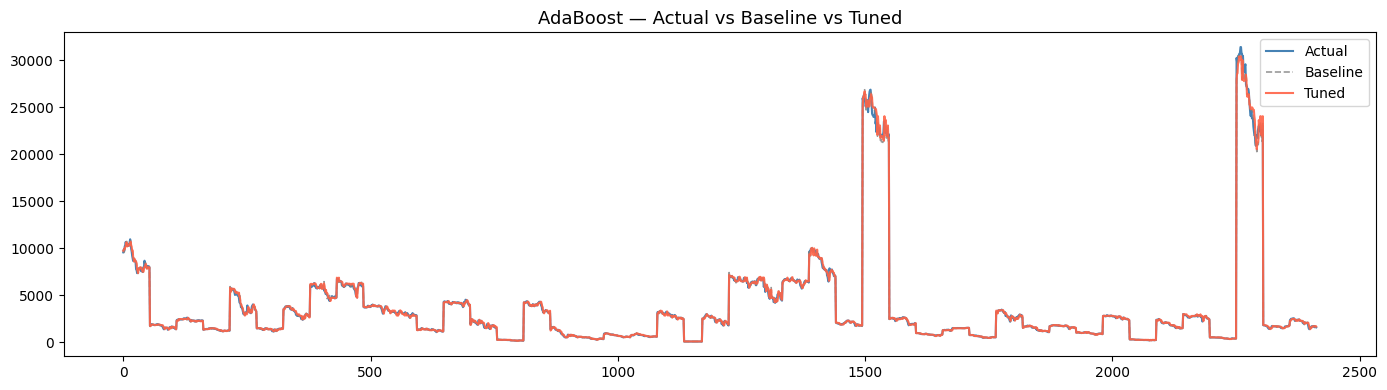


Waktu eksekusi XGBoost (Baseline + Tuning): 1063.76 detik
Waktu eksekusi XGBoost (Baseline + Tuning): 17.73 menit

[SHAP Interpretation] AdaBoost


PermutationExplainer explainer: 2414it [15:55,  2.51it/s]


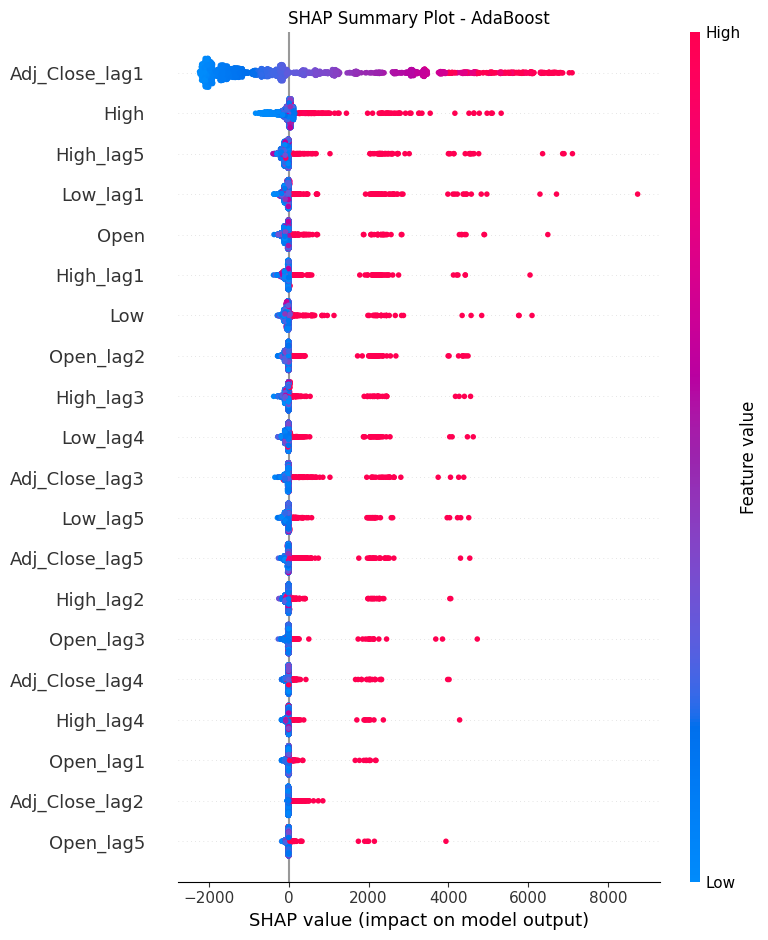

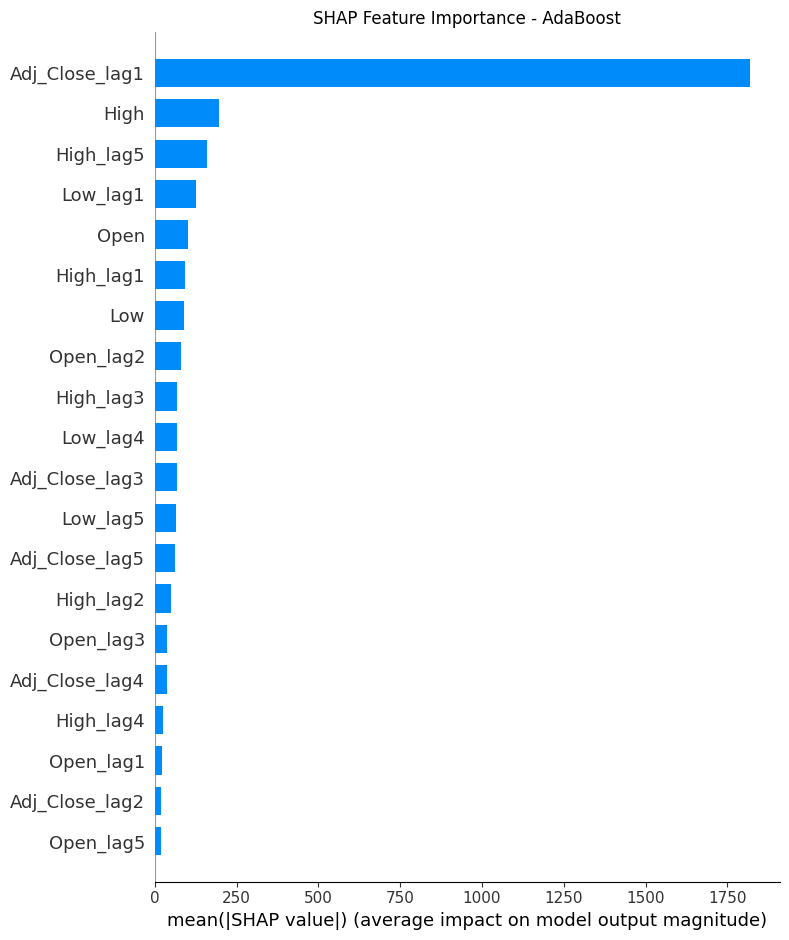

Ticker          : INDF
Observasi index : 1343


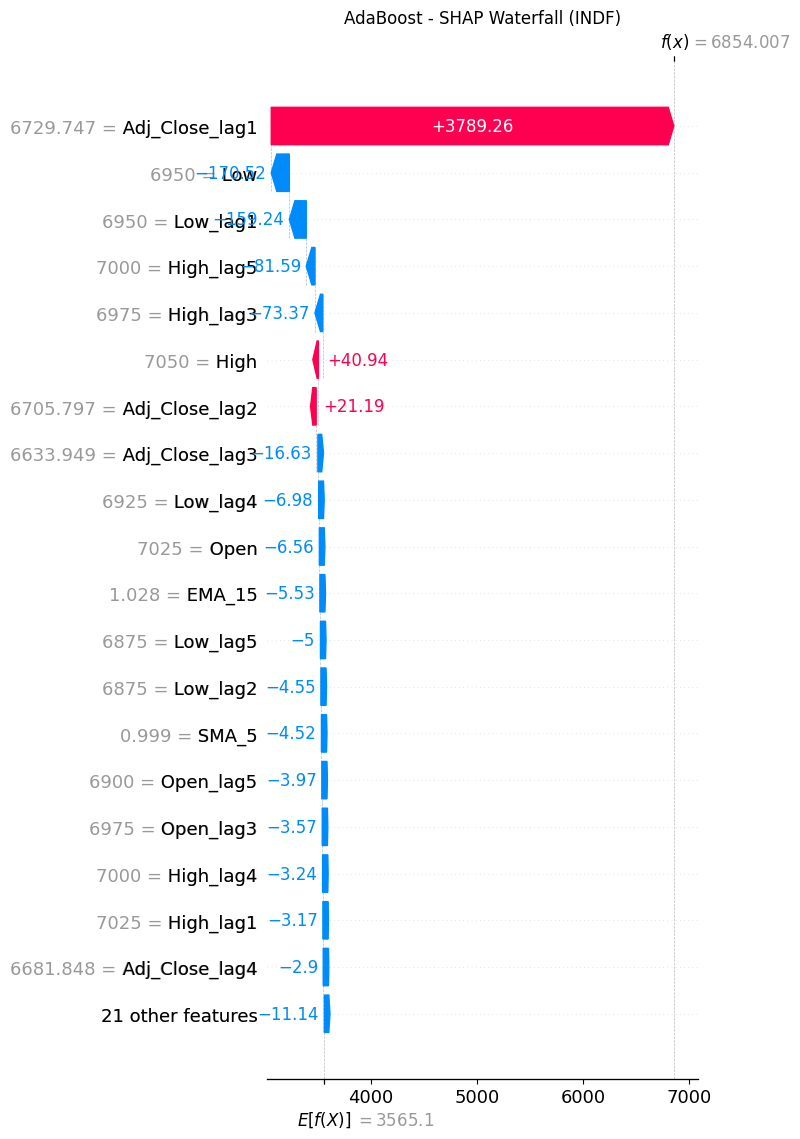


[Per-Ticker Evaluation] AdaBoost Tuned

Top 10 Ticker Terbaik (MAPE terkecil):
Ticker       RMSE        MAE     MAPE       R2
  PTBA  63.765864  45.288454 1.739273 0.808393
  INDF 151.344179 119.392169 1.873764 0.629566
  MAPI  44.162570  26.990140 1.943600 0.822197
  ICBP 180.155342 129.116335 1.986115 0.586068
  ADRO  64.558253  52.095778 2.205065 0.611732
  AKRA  35.174796  28.875300 2.235543 0.886019
  BMRI 127.858536  93.570917 2.246337 0.225744
  BBNI 126.330321  89.976499 2.527709 0.641551
  PGAS  59.534492  40.936479 2.554186 0.700925
  BBCA 235.501162 163.652207 2.771672 0.586149

Top 10 Ticker Terburuk (MAPE terbesar):
Ticker       RMSE        MAE      MAPE         R2
  HRTA 153.459131 119.443329  5.257324   0.780104
  ESSA  44.133316  36.020362  5.321095   0.810111
  INCO 375.572255 284.001975  5.352603   0.816080
  AMMN 282.865557 220.460417  5.613310   0.908206
  DEWA  30.540337  24.547650  6.500261   0.899983
  BUMI  18.122695  13.634788  7.590761   0.781523
  BRPT 197.3

In [18]:
# ADABOOST
import time
from sklearn.tree import DecisionTreeRegressor

print("  ADABOOST")

start_time = time.time()
print("\n[Baseline]")
ada_base = AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=42)
ada_base.fit(X_train, y_train)
ada_pred_base = ada_base.predict(X_test)
ada_result_base = evaluate("AdaBoost Baseline", y_test, ada_pred_base)

print("\n[Tuned — GridSearchCV]")
ada_param_grid = {
    "learning_rate": [0.1, 0.5, 1.0],
    "n_estimators": [50, 100, 200],
    "estimator__max_depth": [6, 8]
}

ada_search = GridSearchCV(
    estimator=AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=42),
    param_grid=ada_param_grid,
    cv=tscv.split(X_train, y_train, groups=groups_train),
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1
)

ada_search.fit(X_train, y_train)
ada_best = ada_search.best_estimator_
ada_pred_tuned = ada_best.predict(X_test)
print("\nBest Parameters")
print(ada_search.best_params_)

print("\nBest CV MAPE (%)")
print(-ada_search.best_score_ * 100)

ada_result_tuned = evaluate("AdaBoost Tuned", y_test, ada_pred_tuned)

print_comparison_table("AdaBoost", ada_result_base, ada_result_tuned)

plot_comparison("AdaBoost", y_test, ada_pred_base, ada_pred_tuned)

end_time = time.time()

execution_time = end_time - start_time

print(f"Waktu eksekusi AdaBoost (Baseline + Tuning): "
      f"{execution_time / 60:.2f} menit")


shap_interpretation(
    model_name="AdaBoost",
    model=ada_best,
    X_train=X_train,
    X_test=X_test,
    ticker_labels=ticker_labels_test,
    waterfall_ticker="INDF",
    max_display=20
)

ada_per_ticker = evaluate_per_ticker(
    "AdaBoost Tuned",
    y_test,
    ada_pred_tuned,
    ticker_labels_test
)

XGBOOST

[Baseline]
RMSE  : 247.5485
MAE   : 113.0220
MAPE  : 3.93%
R2    : 0.9977

[Tuned — GridSearchCV]
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters
{'learning_rate': 0.03, 'max_depth': 8, 'n_estimators': 300}

Best CV MAPE (%)
3.514166945867848
RMSE  : 219.4711
MAE   : 101.9514
MAPE  : 3.45%
R2    : 0.9982

  XGBoost — Baseline vs Tuned
  Metrik         Baseline        Tuned       Diff
  ----------------------------------------------
  MAE            113.0220     101.9514 ↓ 11.0707 ✅
  RMSE           247.5485     219.4711 ↓ 28.0775 ✅
  MAPE             3.9278       3.4505 ↓  0.4774 ✅
  R2               0.9977       0.9982 ↑  0.0005 ✅


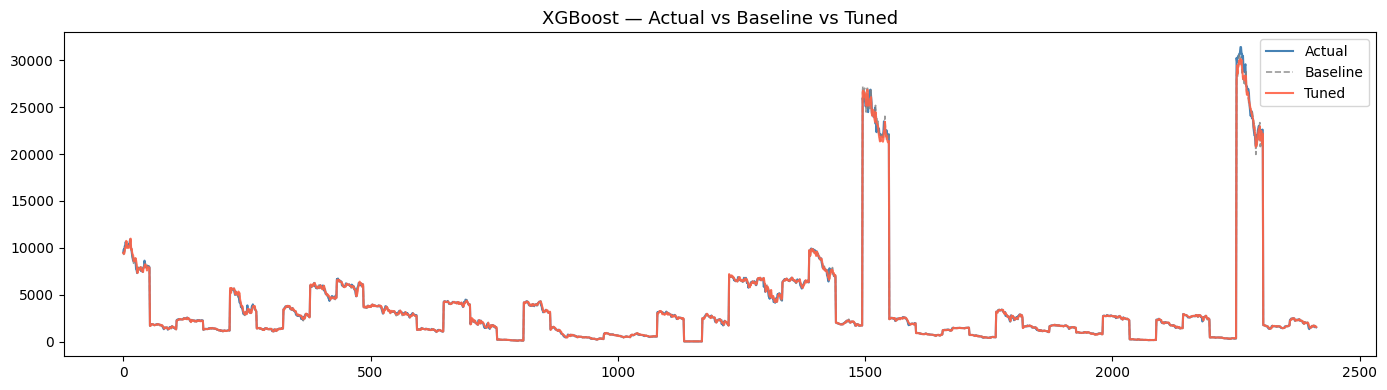


Waktu eksekusi XGBoost (Baseline + Tuning): 299.92 detik
Waktu eksekusi XGBoost (Baseline + Tuning): 5.00 menit

[SHAP Interpretation] XGBoost


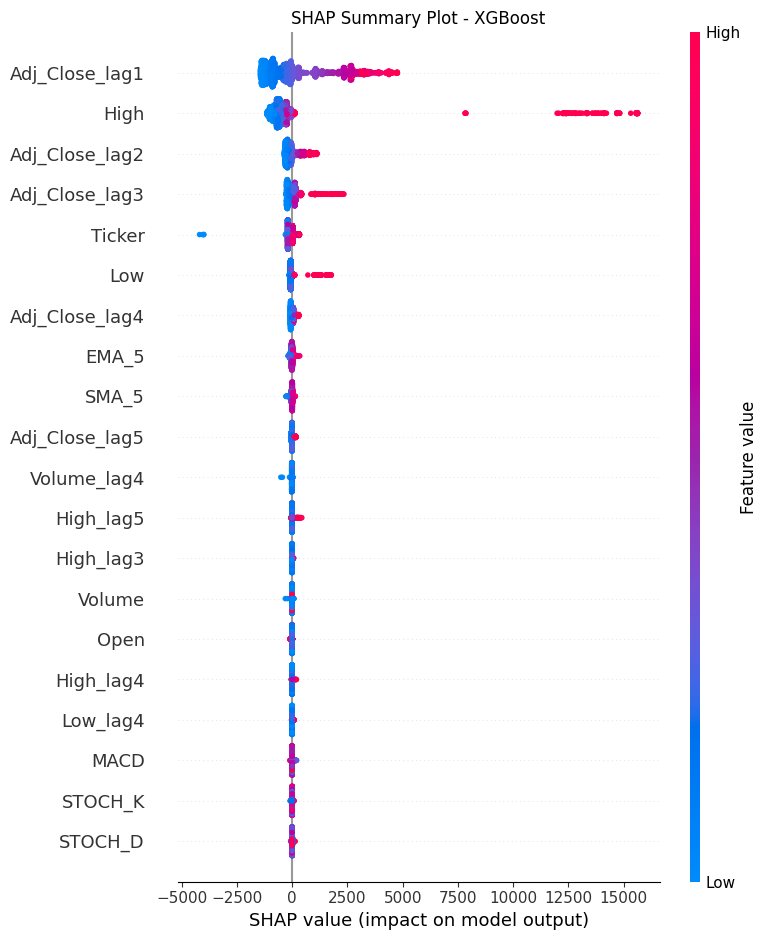

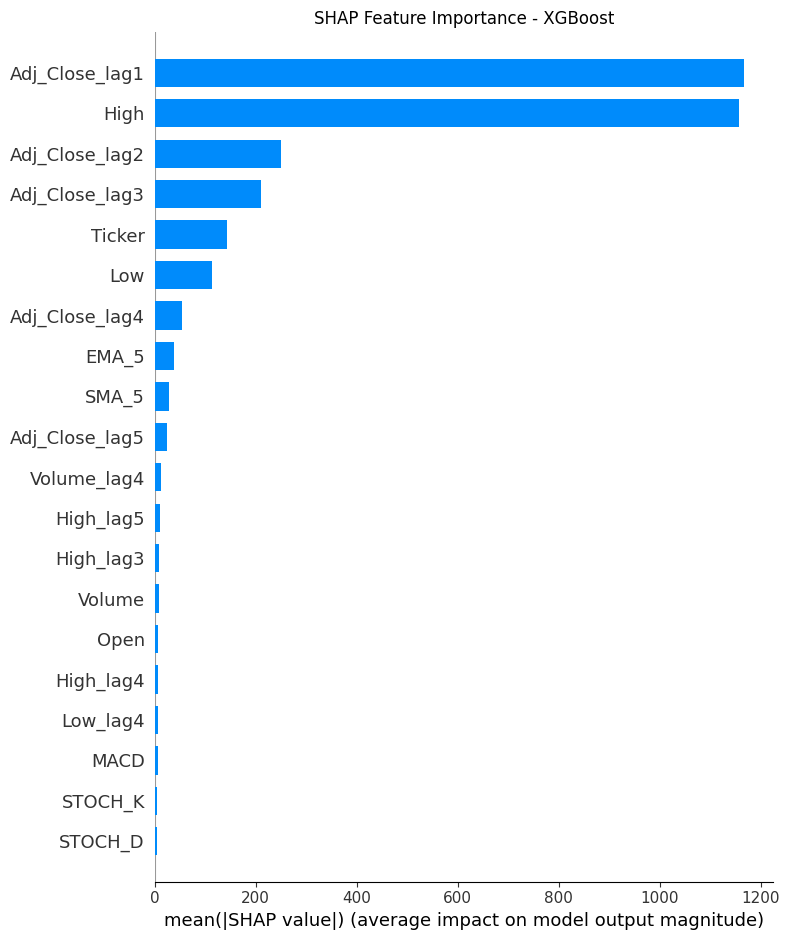

Ticker          : INDF
Observasi index : 1352


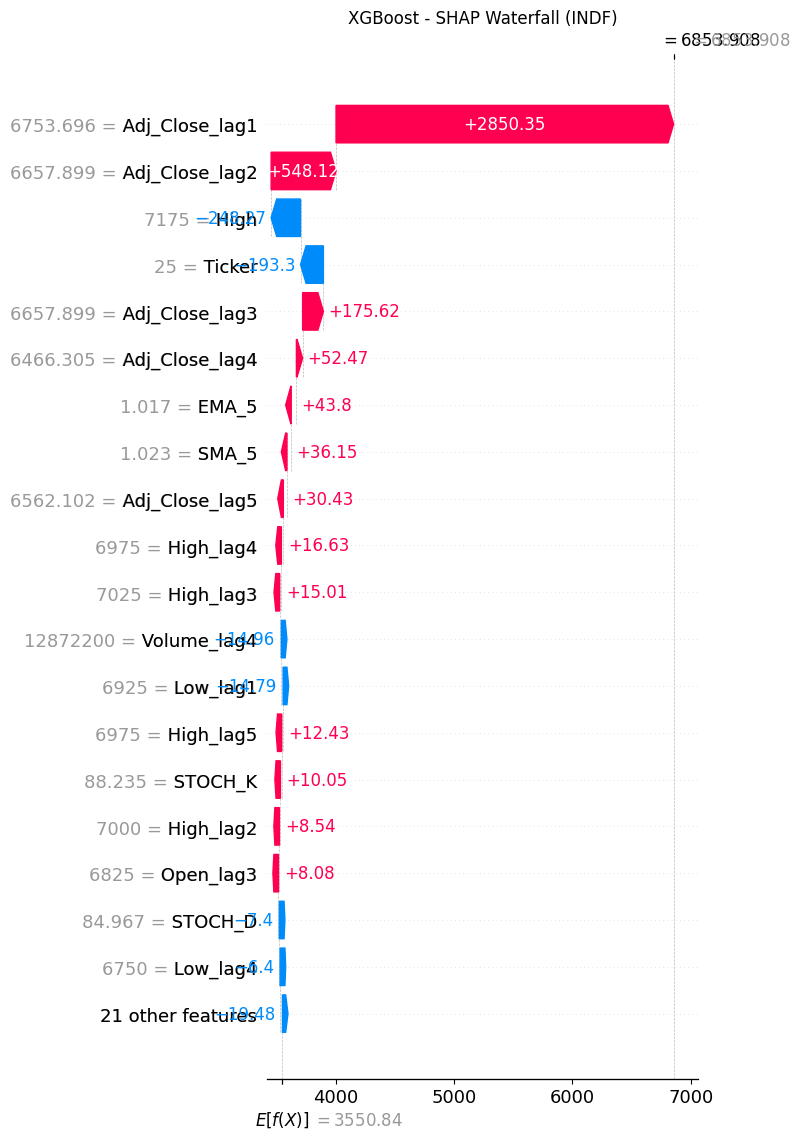


[Per-Ticker Evaluation] XGBoost Tuned

Top 10 Ticker Terbaik (MAPE terkecil):
Ticker       RMSE        MAE     MAPE       R2
  INDF 133.761474 102.660066 1.616769 0.710638
  PTBA  62.765629  43.905839 1.682836 0.814357
  ICBP 152.597252 111.572564 1.721218 0.703019
  MAPI  38.772059  24.652269 1.787478 0.862953
  AKRA  28.824439  23.409327 1.810449 0.923459
  BMRI 102.383480  77.045392 1.841311 0.503539
  ADRO  64.273262  47.244416 2.001564 0.615153
  PGAS  44.926178  32.786879 2.034781 0.829689
  ISAT  56.203179  41.363600 2.098596 0.883929
  TLKM  94.687284  55.498513 2.145111 0.596415

Top 10 Ticker Terburuk (MAPE terbesar):
Ticker       RMSE        MAE      MAPE         R2
  MDKA 141.770880 108.714785  3.974239   0.822499
  ESSA  38.607818  29.998735  4.395141   0.854683
  SCMA  13.430446  10.211121  4.444250   0.752853
  INCO 323.954391 242.106744  4.675388   0.863161
  BUMI  11.704146   9.390115  5.045890   0.908875
  DEWA  26.288881  20.715489  5.240147   0.925891
  AMMN 282.21

In [17]:
# XGBOOST
import time
print("XGBOOST")

start_time = time.time()
print("\n[Baseline]")
xgb_base = XGBRegressor(random_state=42, verbosity=0)
xgb_base.fit(X_train, y_train)
xgb_pred_base = xgb_base.predict(X_test)
xgb_result_base = evaluate("XGBoost Baseline", y_test, xgb_pred_base)

print("\n[Tuned — GridSearchCV]")

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.15, 0.3],
    "max_depth": [6, 8]
}

cv_folds = list(tscv.split(X_train, y_train, groups=groups_train))

xgb_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42, verbosity=0),
    param_grid=xgb_param_grid,
    cv=cv_folds,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_
xgb_pred_tuned = xgb_best.predict(X_test)

print("\nBest Parameters")
print(xgb_search.best_params_)

print("\nBest CV MAPE (%)")
print(-xgb_search.best_score_ * 100)

xgb_result_tuned = evaluate("XGBoost Tuned", y_test, xgb_pred_tuned)

print_comparison_table("XGBoost", xgb_result_base, xgb_result_tuned)

plot_comparison("XGBoost", y_test, xgb_pred_base, xgb_pred_tuned)

end_time = time.time()

execution_time = end_time - start_time

print(f"Waktu eksekusi XGBoost (Baseline + Tuning): "
      f"{execution_time / 60:.2f} menit")


# SHAP (Waterfall khusus INDF)
shap_interpretation(
    model_name="XGBoost",
    model=xgb_best,
    X_train=X_train,
    X_test=X_test,
    ticker_labels=ticker_labels_test,
    waterfall_ticker="INDF",
    max_display=20
)

xgb_per_ticker = evaluate_per_ticker(
    "XGBoost Tuned",
    y_test,
    xgb_pred_tuned,
    ticker_labels_test
)

  LIGHTGBM

[Baseline]
RMSE  : 219.5599
MAE   : 103.6983
MAPE  : 3.86%
R2    : 0.9982

[Tuned — GridSearchCV]
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters
{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300}

Best CV MAPE (%)
3.5492944799662243
RMSE  : 219.5462
MAE   : 102.4493
MAPE  : 3.54%
R2    : 0.9982

  LightGBM — Baseline vs Tuned
  Metrik         Baseline        Tuned       Diff
  ----------------------------------------------
  MAE            103.6983     102.4493 ↓  1.2489 ✅
  RMSE           219.5599     219.5462 ↓  0.0137 ✅
  MAPE             3.8650       3.5406 ↓  0.3244 ✅
  R2               0.9982       0.9982 ↑  0.0000 ✅


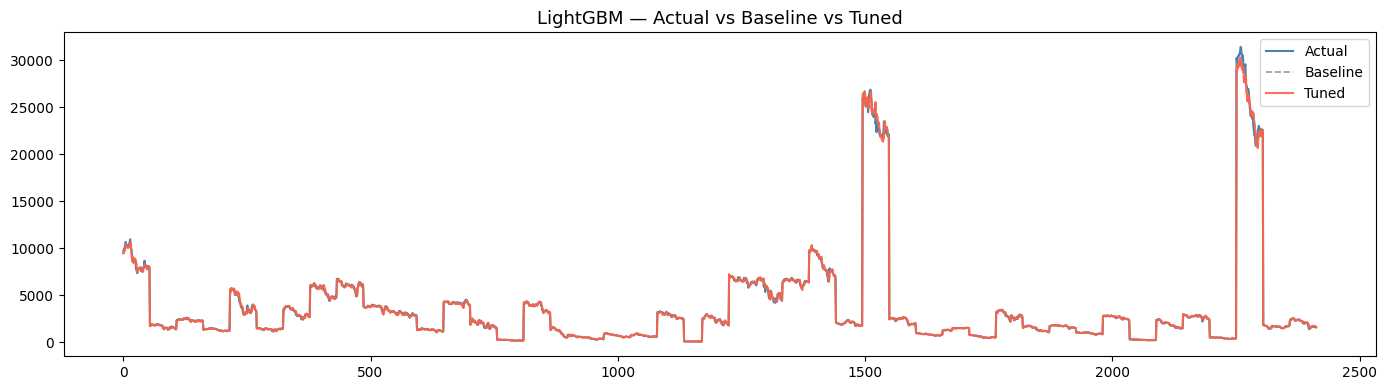


Waktu eksekusi LightGBM (Baseline + Tuning): 64.85 detik
Waktu eksekusi LightGBM (Baseline + Tuning): 1.08 menit

[SHAP Interpretation] LightGBM


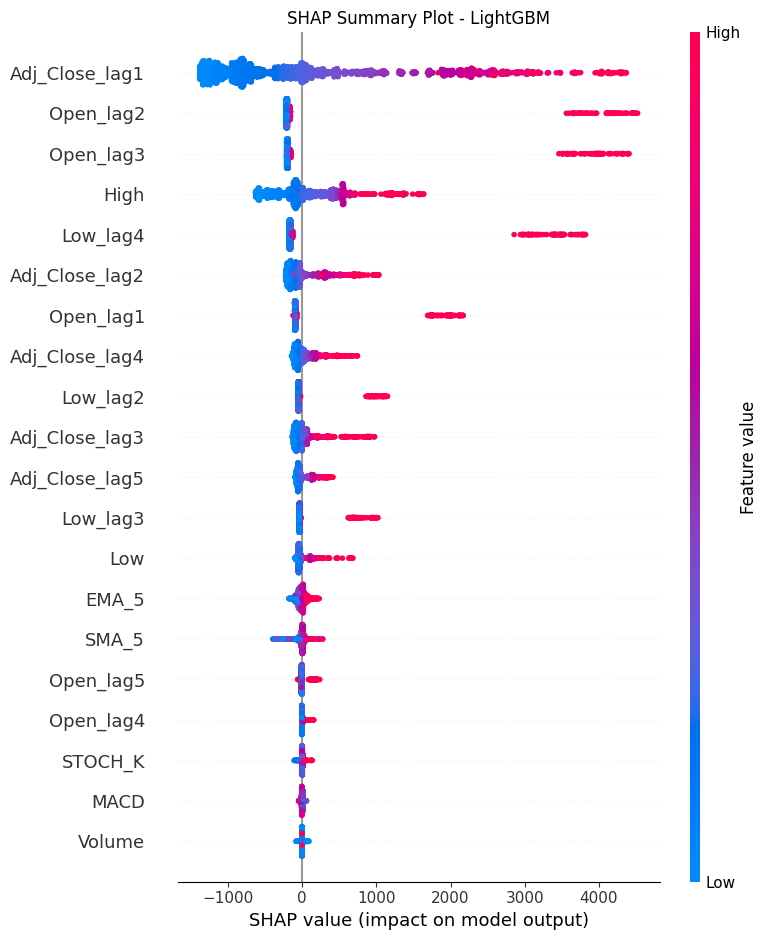

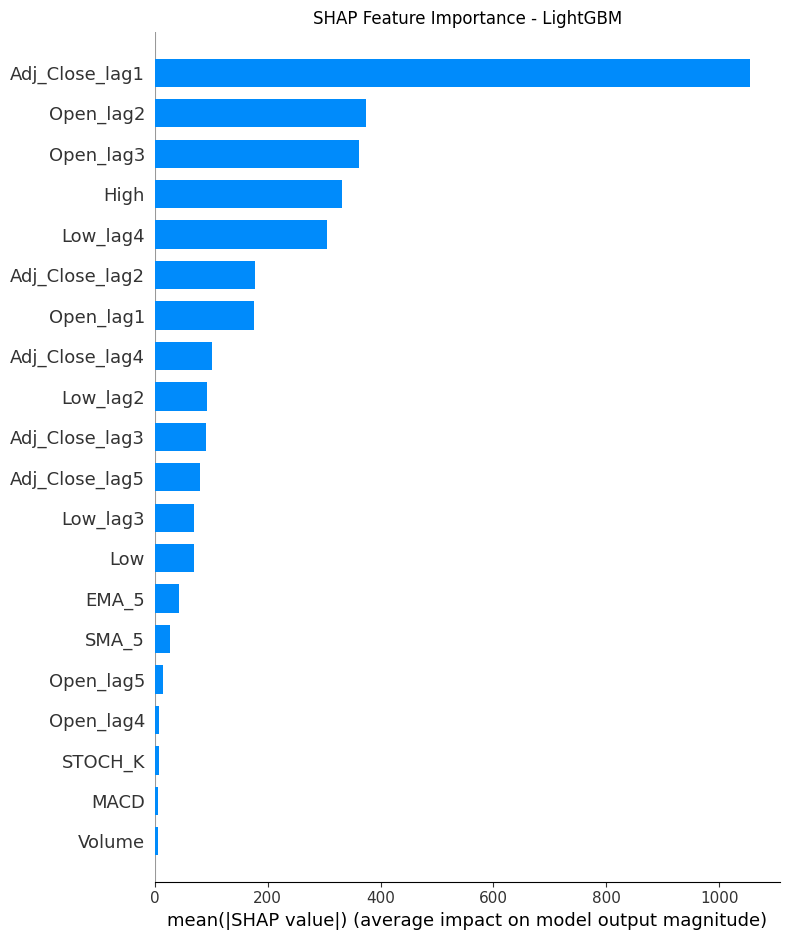

Ticker          : INDF
Observasi index : 1352


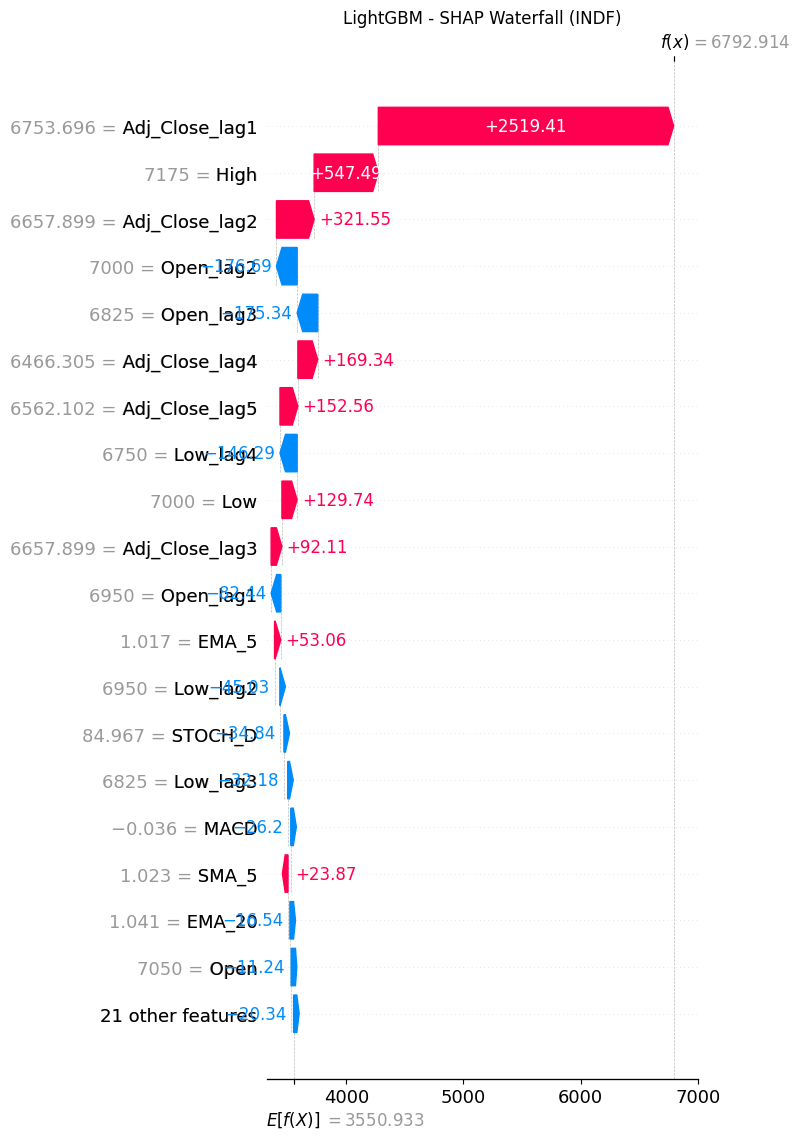


[Per-Ticker Evaluation] LightGBM Tuned

Top 10 Ticker Terbaik (MAPE terkecil):
Ticker       RMSE        MAE     MAPE       R2
  INDF 135.018679 100.446977 1.577161 0.705173
  ICBP 148.389875 105.805406 1.625730 0.719170
  PTBA  59.704966  44.707137 1.709129 0.832021
  AKRA  31.831435  26.050309 1.992183 0.906657
  PGAS  44.208851  32.159343 1.995710 0.835085
  MAPI  40.020911  27.455634 1.997079 0.853982
  BMRI 122.127202  84.830325 2.018849 0.293601
  UNVR  48.656969  34.070924 2.144328 0.782267
  BBCA 182.966567 130.639383 2.215995 0.750195
  INKP 259.392062 180.201370 2.223309 0.942468

Top 10 Ticker Terburuk (MAPE terbesar):
Ticker       RMSE        MAE      MAPE         R2
  INCO 312.825208 221.610757  4.243883   0.872402
  HRTA 128.186205  98.010612  4.319373   0.846569
  ESSA  40.257336  31.526277  4.667116   0.842000
  AMMN 255.482628 196.244820  4.944685   0.925118
  SCMA  15.556588  11.731634  5.002529   0.668409
  BUMI  11.550019   9.246224  5.047252   0.911259
  DEWA  25.5

In [16]:
# LIGHTGBM
import time
print("LIGHTGBM")

start_time = time.time()
print("\n[Baseline]")
lgbm_base = LGBMRegressor(random_state=42, verbose=-1)
lgbm_base.fit(X_train, y_train)
lgbm_pred_base = lgbm_base.predict(X_test)
lgbm_result_base = evaluate("LightGBM Baseline", y_test, lgbm_pred_base)


print("\n[Tuned — GridSearchCV]")

lgbm_param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300],
    "max_depth": [6, 8]
}

cv_folds = list(tscv.split(X_train, y_train, groups=groups_train))

lgbm_search = GridSearchCV(
    estimator=LGBMRegressor(random_state=42, verbose=-1),
    param_grid=lgbm_param_grid,
    cv=cv_folds,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_train, y_train)
lgbm_best = lgbm_search.best_estimator_
lgbm_pred_tuned = lgbm_best.predict(X_test)

print("\nBest Parameters")
print(lgbm_search.best_params_)

print("\nBest CV MAPE (%)")
print(-lgbm_search.best_score_ * 100)

lgbm_result_tuned = evaluate("LightGBM Tuned", y_test, lgbm_pred_tuned)

print_comparison_table("LightGBM", lgbm_result_base, lgbm_result_tuned)

plot_comparison("LightGBM", y_test, lgbm_pred_base, lgbm_pred_tuned)

end_time = time.time()

execution_time = end_time - start_time

print(f"Waktu eksekusi LightGBM (Baseline + Tuning): "
      f"{execution_time / 60:.2f} menit")


shap_interpretation(
    model_name="LightGBM",
    model=lgbm_best,
    X_train=X_train,
    X_test=X_test,
    ticker_labels=ticker_labels_test,
    waterfall_ticker="INDF",
    max_display=20
)

lgbm_per_ticker = evaluate_per_ticker(
    "LightGBM Tuned",
    y_test,
    lgbm_pred_tuned,
    ticker_labels_test
)

  CATBOOST

[Baseline]
RMSE  : 249.6359
MAE   : 119.0493
MAPE  : 4.59%
R2    : 0.9976

[Tuned — GridSearchCV]
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters
{'iterations': 3000, 'learning_rate': 0.0329, 'max_depth': 6}

Best CV MAPE (%)
4.091731968642481
RMSE  : 249.7183
MAE   : 117.2146
MAPE  : 4.37%
R2    : 0.9976

  CatBoost — Baseline vs Tuned
  Metrik         Baseline        Tuned       Diff
  ----------------------------------------------
  MAE            119.0493     117.2146 ↓  1.8346 ✅
  RMSE           249.6359     249.7183 ↑  0.0824 ❌
  MAPE             4.5939       4.3651 ↓  0.2288 ✅
  R2               0.9976       0.9976 ↓  0.0000 ❌


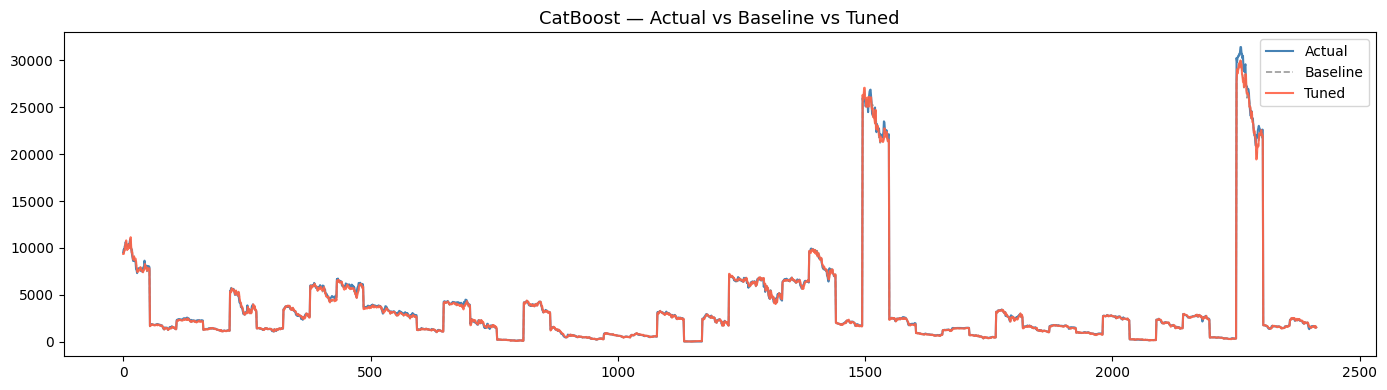


Waktu eksekusi LightGBM (Baseline + Tuning): 5052.78 detik
Waktu eksekusi LightGBM (Baseline + Tuning): 84.21 menit

[SHAP Interpretation] CatBoost


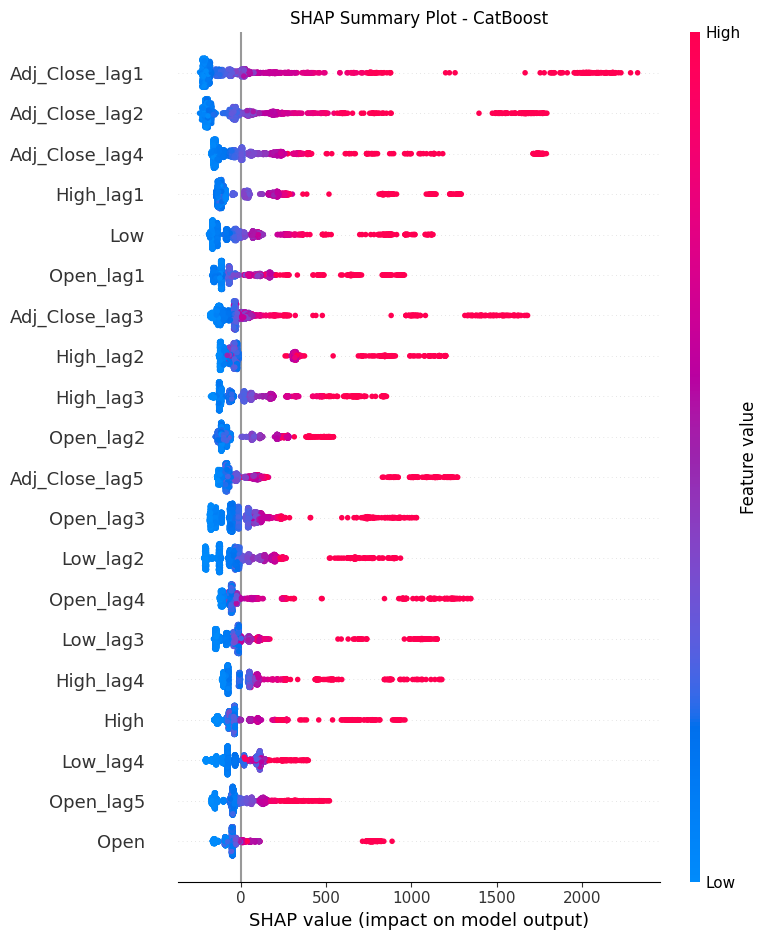

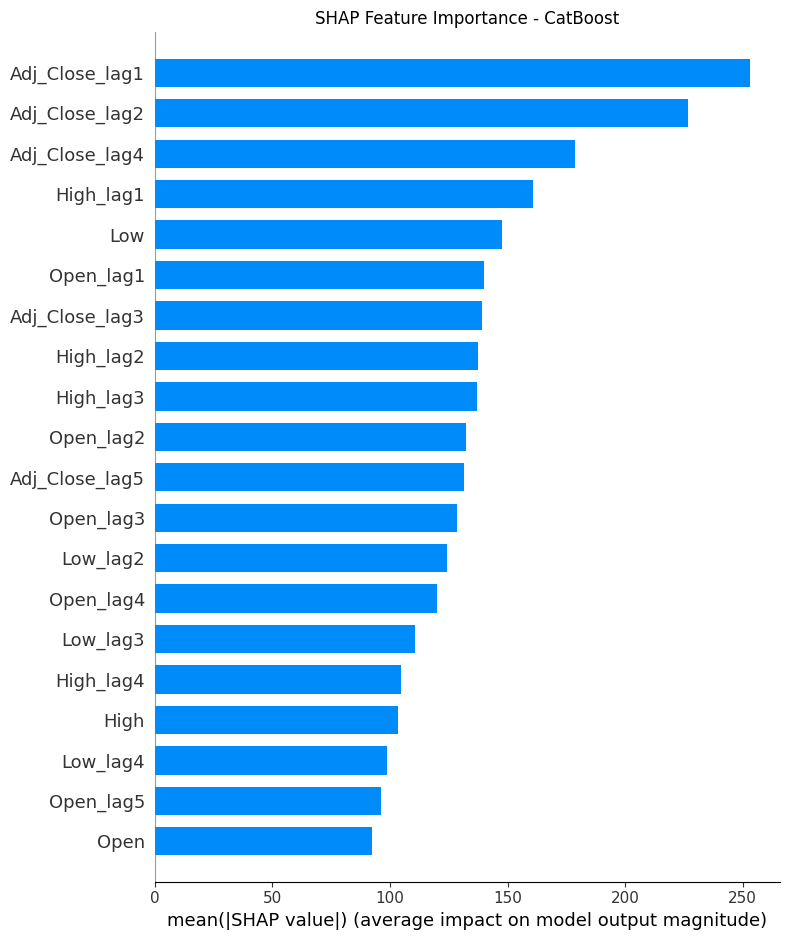

Ticker          : INDF
Observasi index : 1352


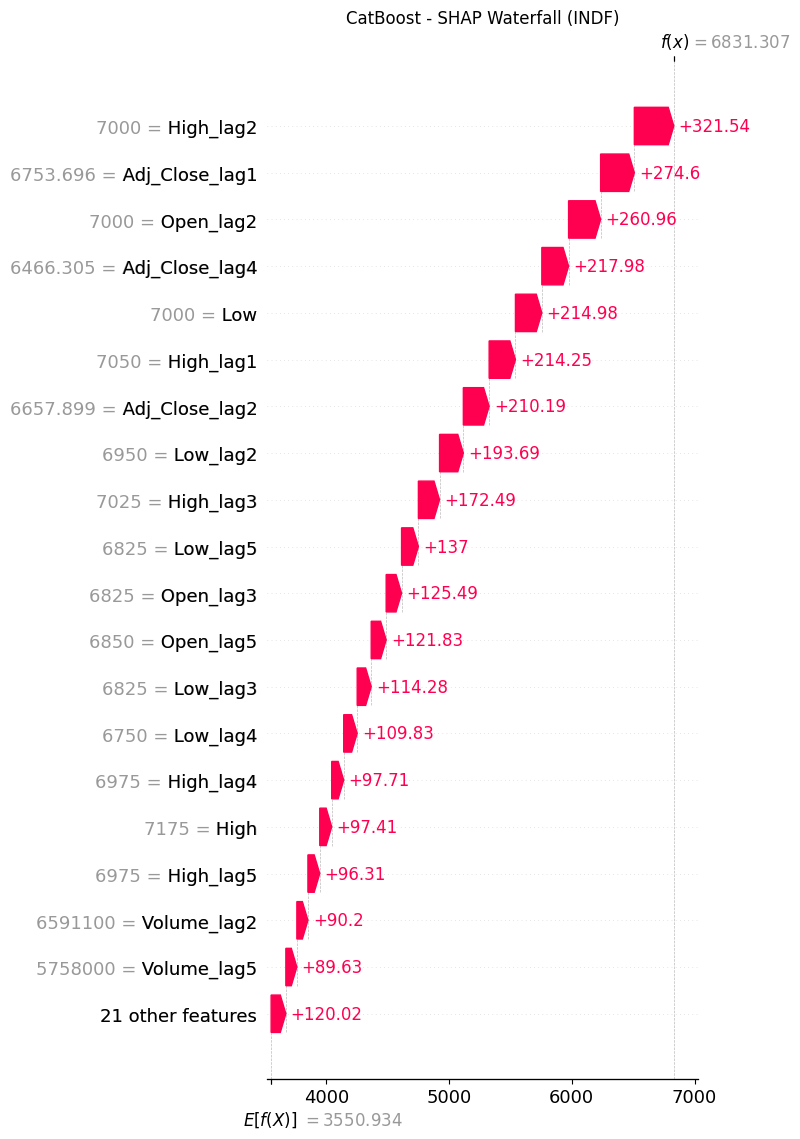


[Per-Ticker Evaluation] CatBoost Tuned

Top 10 Ticker Terbaik (MAPE terkecil):
Ticker       RMSE        MAE     MAPE       R2
  PTBA  58.372363  42.975131 1.637399 0.839436
  INDF 143.334154 111.938364 1.759461 0.667739
  ICBP 161.369298 118.506111 1.821843 0.667894
  ITMG 694.765267 555.451585 2.321014 0.821935
  AKRA  37.537508  30.964772 2.360950 0.870192
  CPIN 118.319250  88.382884 2.377078 0.910361
  INKP 246.813290 195.309707 2.396623 0.947912
  SMGR  58.131391  45.892693 2.516529 0.964066
  TLKM  94.984027  66.748529 2.558457 0.593881
  EXCL  95.584152  75.178819 2.636101 0.863887

Top 10 Ticker Terburuk (MAPE terbesar):
Ticker       RMSE        MAE      MAPE          R2
  ESSA  36.207876  28.506519  4.236570    0.872188
  BBRI 161.639948 136.929119  4.505515   -0.070669
  MBMA  33.475099  26.775335  4.948024    0.899391
  AMMN 261.200304 201.131242  5.089081    0.921729
  DEWA  28.697211  23.241200  5.767088    0.911691
  BRPT 162.959951 131.288291  7.003609    0.676418
  CUA

In [19]:
import time
print("  CATBOOST")

start_time = time.time()
cat_feature_names = ["Ticker"]

cat_features_idx = [
    X_train.columns.get_loc(c)
    for c in cat_feature_names
]

print("\n[Baseline]")

cat_base = CatBoostRegressor(
    random_state=42,
    verbose=0,
    cat_features=cat_features_idx
)

cat_base.fit(
    X_train,
    y_train
)

cat_pred_base = cat_base.predict(X_test)

cat_result_base = evaluate(
    "CatBoost Baseline",
    y_test,
    cat_pred_base
)


print("\n[Tuned — GridSearchCV]")

cat_param_grid = {
    "learning_rate": [0.0066, 0.0329, 0.0658],
    "iterations": [1000, 2000, 3000],
    "max_depth": [6, 8]
}

cv_folds = list(
    tscv.split(
        X_train,
        y_train,
        groups=groups_train
    )
)

cat_search = GridSearchCV(
    estimator=CatBoostRegressor(
        random_state=42,
        verbose=0
    ),
    param_grid=cat_param_grid,
    cv=cv_folds,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1
)

cat_search.fit(
    X_train,
    y_train,
    cat_features=cat_features_idx
)

cat_best = cat_search.best_estimator_

cat_pred_tuned = cat_best.predict(X_test)

print("\nBest Parameters")
print(cat_search.best_params_)

print("\nBest CV MAPE (%)")
print(-cat_search.best_score_ * 100)


cat_result_tuned = evaluate(
    "CatBoost Tuned",
    y_test,
    cat_pred_tuned
)

print_comparison_table(
    "CatBoost",
    cat_result_base,
    cat_result_tuned
)

plot_comparison(
    "CatBoost",
    y_test,
    cat_pred_base,
    cat_pred_tuned
)

end_time = time.time()

execution_time = end_time - start_time

print(f"Waktu eksekusi CatBoost (Baseline + Tuning): "
      f"{execution_time / 60:.2f} menit")

shap_interpretation(
    model_name="CatBoost",
    model=cat_best,
    X_train=X_train,
    X_test=X_test,
    ticker_labels=ticker_labels_test,
    waterfall_ticker="INDF",
    max_display=20
)

cat_per_ticker = evaluate_per_ticker(
    "CatBoost Tuned",
    y_test,
    cat_pred_tuned,
    ticker_labels_test
)

In [ ]:
from catboost import CatBoostRegressor

cat_default = CatBoostRegressor(random_state=42, verbose=0)
cat_default.fit(X_train, y_train)

print(cat_default.get_all_params())

{'nan_mode': 'Min', 'eval_metric': 'RMSE', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'rsm': 1, 'boost_from_average': True, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'random_seed': 42, 'depth': 6, 'posterior_sampling': False, 'border_count': 254, 'classes_count': 0, 'auto_class_weights': 'None', 'sparse_features_conflict_fraction': 0, 'leaf_estimation_backtracking': 'AnyImprovement', 'best_model_min_trees': 1, 'model_shrink_rate': 0, 'min_data_in_leaf': 1, 'loss_function': 'RMSE', 'learning_rate': 0.06576500087976456, 

In [ ]:
# XGBoost
xgb_default = XGBRegressor(random_state=42, verbosity=0)
xgb_default.fit(X_train, y_train)
print("XGBoost params:", xgb_default.get_params())

# LightGBM
from lightgbm import LGBMRegressor
lgb_default = LGBMRegressor(random_state=42)
lgb_default.fit(X_train, y_train)
print("LightGBM params:", lgb_default.get_params())

# AdaBoost
from sklearn.ensemble import AdaBoostRegressor
ada_default = AdaBoostRegressor(random_state=42)
ada_default.fit(X_train, y_train)
print("AdaBoost params:", ada_default.get_params())

XGBoost params: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': 0}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the ov

In [ ]:
xgb_default = XGBRegressor(random_state=42, verbosity=0)
xgb_default.fit(X_train, y_train)

# Cara paling akurat: cek dari booster config
import json
config = json.loads(xgb_default.get_booster().save_config())
print("learning_rate (eta):", config['learner']['gradient_booster']['tree_train_param']['eta'])
print("max_depth:", config['learner']['gradient_booster']['tree_train_param']['max_depth'])

learning_rate (eta): 0.300000012
max_depth: 6


In [ ]:
xgb_default = XGBRegressor(random_state=42, verbosity=0)
xgb_default.fit(X_train, y_train)

# Cek learning_rate dan max_depth dari booster config
import json
config = json.loads(xgb_default.get_booster().save_config())
print("learning_rate (eta):", config['learner']['gradient_booster']['tree_train_param']['eta'])
print("max_depth:", config['learner']['gradient_booster']['tree_train_param']['max_depth'])

# Cek n_estimators (jumlah boosting rounds)
print("n_estimators:", xgb_default.get_num_boosting_rounds())

learning_rate (eta): 0.300000012
max_depth: 6
n_estimators: 100
